In [1]:
import pandas as pd
df_mpra = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv' , index_col=0)
df_mpra = df_mpra.drop_duplicates(subset='enhancer_id',keep='first')
df_500 = df_mpra

def pad_sequence(seq):
    if len(seq) < 500:
        left = (500 - len(seq))//2 * 'N'
        right =(500 - len(seq) - len(left)) * 'N'
        return left + seq + right
    else:
        return seq

# Apply the function to the 'full_seq' column
df_500['padded_seq'] = df_500['enhancer_seq'].apply(pad_sequence)
# Function to save the DataFrame as a FASTA file
def save_as_fasta(df, file_name):
    with open(file_name, 'w') as f:
        for index, row in df.iterrows():
            f.write(f">{row['enhancer_id']}\n")
            f.write(f"{row['padded_seq']}\n")

save_as_fasta(df_500, '20241001_MPRA_500bp_SNPandControl_Ns_227bpenhancers.fasta')
df_500 = df_500.reset_index()
df_500.to_csv("20241001_MPRA_500bp_SNPandControl_Ns_227bpenhancers.csv")

In [1]:
import numpy as np
import logomaker

def process_and_plot_shap(
    npz_file_path, 
    seq_file_path, 
    major_index, 
    minor_index, 
    start, 
    end, 
    major_output_file='', 
    minor_output_file='', 
    diff_output_file='', 
    figure_size=(10, 3),
    neuron = False,
    neuron_model=['fullard_DLPFC-model-best_SHAP','fullard_hippocampus-model-best_SHAP','fullard_Putamen-model-best_SHAP']
):
    """
    Load SHAP scores and sequence data, process them, and generate SHAP logo plots.

    Parameters:
        npz_file_path (str): Path to the .npz file containing SHAP scores.
        seq_file_path (str): Path to the .npz file containing one-hot encoded sequences.
        major_index (int): Index for the major allele.
        minor_index (int): Index for the minor allele.
        start (int): Start index for the region of interest.
        end (int): End index for the region of interest.
        major_output_file (str): Output file path for the major allele SHAP logo.
        minor_output_file (str): Output file path for the minor allele SHAP logo.
        diff_output_file (str): Output file path for the difference SHAP logo.
        figure_size (tuple): Size of the output figure.
    """
    print(npz_file_path)
    if neuron:
        # Load data
        all_scores_major = []
        all_scores_minor = []
        for f in neuron_model:#,,'['Mouse_Cortex_AgeB-model-best_SHAP','Mouse_Cortex_AgeC-model-best_SHAP','Mouse_Striatum_AgeB-model-best_SHAP','Mouse_Striatum_AgeC-model-best_SHAP']:
            npz_file_path = f'../mpra3_interpretation/shap_values_genomic_500bp_matched_background/{f}/attributions_from_shap.npz'
            seq_file_path = f'../mpra3_interpretation/shap_values_genomic_500bp_matched_background/{f}/onehot_encoded_sequences.npz'
            shap_data = np.load(npz_file_path)
            seq_data = np.load(seq_file_path)
            shap_scores_raw = np.array(shap_data['arr_0'])
            seq_raw = np.array(seq_data['arr_0'])

            # Adjust SHAP scores using one-hot encoding
            shap_scores_raw = shap_scores_raw * seq_raw

            # Squeeze the array to remove unnecessary dimensions
            shap_scores_squeezed = np.squeeze(shap_scores_raw)

            # Extract SHAP scores for the selected range
            major_scores = shap_scores_squeezed[major_index][start:end]
            minor_scores = shap_scores_squeezed[minor_index][start:end]

            all_scores_major.append(major_scores)
            all_scores_minor.append(minor_scores)
            major_scores = np.sum(all_scores_major, axis=0)
            minor_scores = np.sum(all_scores_minor, axis=0)    
    elif not neuron:
        shap_data = np.load(npz_file_path)
        seq_data = np.load(seq_file_path)
        shap_scores_raw = np.array(shap_data['arr_0'])
        seq_raw = np.array(seq_data['arr_0'])

        # Adjust SHAP scores using one-hot encoding
        shap_scores_raw = shap_scores_raw * seq_raw

        # Squeeze the array to remove unnecessary dimensions
        shap_scores_squeezed = np.squeeze(shap_scores_raw)

        # Extract SHAP scores for the selected range
        major_scores = shap_scores_squeezed[major_index][start:end]
        minor_scores = shap_scores_squeezed[minor_index][start:end]

    # Calculate y-axis range dynamically
    combined_scores = np.concatenate((major_scores, minor_scores))
    y_min = np.min(combined_scores)
    y_max = np.max(combined_scores)
    # Plot major SHAP logo
    plot_shap_logo(
        major_scores, 
        output_file=major_output_file, 
        start=start, 
        end=end, 
        figure_size=figure_size, 
        y_range=(y_min, y_max)
    )

    # Plot minor SHAP logo
    plot_shap_logo(
        minor_scores, 
        output_file=minor_output_file, 
        start=start, 
        end=end, 
        figure_size=figure_size, 
        y_range=(y_min, y_max)
    )

    # Plot difference SHAP logo
    plot_shap_logo(
        major_scores - minor_scores, 
        output_file=diff_output_file, 
        start=start, 
        end=end, 
        figure_size=figure_size
    )
import pandas as pd
import matplotlib.pyplot as plt
import logomaker
import matplotlib.ticker as ticker

def plot_shap_logo(shap_scores_squeezed, output_file, start=-113, end=113, 
                  figure_size=(40, 5), y_range=None):
    """
    Plot a SHAP logo for an enhancer using nucleotide SHAP scores.

    Parameters:
    shap_scores_squeezed (np.array): Squeezed SHAP scores array.
    output_file (str): File name to save the plot as a PDF.
    start (int, optional): Start position for slicing. Default is -113.
    end (int, optional): End position for slicing. Default is 113.
    figure_size (tuple, optional): Size of the figure. Default is (40, 5).
    y_range (tuple, optional): Y-axis limits as (y_min, y_max). 
                                If None, defaults to the data's range.

    Returns:
    None
    """
    # Validate y_range if provided
    if y_range is not None:
        if (not isinstance(y_range, tuple)) or (len(y_range) != 2):
            raise ValueError("y_range must be a tuple of two numerical values (y_min, y_max).")
        if not all(isinstance(val, (int, float)) for val in y_range):
            raise TypeError("Both elements in y_range must be integers or floats.")

    # Extract SHAP scores for the specific enhancer
    shap_scores_enhancer = shap_scores_squeezed

    # Create a dictionary with nucleotide bases as keys and SHAP scores as values
    nucleotide_bases = ['A', 'C', 'G', 'T']
    shap_scores_dict = {nucleotide_bases[i]: shap_scores_enhancer[i].tolist() for i in range(4)}

    # Convert the dictionary to a pandas DataFrame
    # Adjust the slicing indices based on 'start' and 'end'
    # Note: Ensure that the slicing does not result in an empty DataFrame
    slice_start = 136 + 113 + start+1
    slice_end = 363 - 113 + end+1
    shap_scores_df = pd.DataFrame(shap_scores_dict).iloc[slice_start:slice_end]

    # Check if the sliced DataFrame is empty
    if shap_scores_df.empty:
        raise ValueError("The sliced DataFrame is empty. Please check your 'start' and 'end' parameters.")

    # Set the index to represent positions
    shap_scores_df.index = range(start, end + 1)

    # Create a figure and axis with a specific size and DPI
    fig, ax = plt.subplots(figsize=figure_size)

    # Create the sequence logo plot using logomaker
    shap_logo = logomaker.Logo(shap_scores_df, ax=ax)

    # Customize the appearance of the logo plot
    shap_logo.style_spines(visible=False)
    shap_logo.style_spines(spines=['left', 'bottom'], visible=True)
    shap_logo.ax.set_ylabel('Importance Score', fontsize=13)
    shap_logo.ax.set_xlabel('Relative Position', fontsize=13)

    # **Set x-axis to display only integer ticks**
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # **Set y-axis range if y_range is provided**
    if y_range is not None:
        ax.set_ylim(y_range)
    plt.tight_layout()
    # Save the figure with the specified resolution
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Display the plot
    plt.show()



In [ ]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import logomaker

# ============================================================
# Default model collections
# ============================================================
DEFAULT_NEURON_MODELS = [
    'fullard_DLPFC-model-best_SHAP',
    # 'fullard_hippocampus-model-best_SHAP',
    # 'fullard_Putamen-model-best_SHAP'
]

DEFAULT_THP1_MODELS = [
    'THP1_Naive-model-best_SHAP',
    # 'THP1_IFNB-model-best_SHAP',
    # 'THP1_IFNG-model-best_SHAP',
    # 'THP1_LPSIFNG_Calvin_SHAP'
]

BASE_DIR = '../mpra3_interpretation/shap_values_genomic_500bp_matched_background'


# ============================================================
# Core loading / preprocessing
# ============================================================
def _load_shap_and_seq(npz_file_path, seq_file_path):
    """
    Load SHAP and sequence arrays; multiply SHAP by one-hot sequence.
    Returns shape (N, 4, L) after squeeze-compatible loading.
    """
    shap_data = np.load(npz_file_path)
    seq_data = np.load(seq_file_path)

    shap_scores_raw = np.array(shap_data['arr_0'])
    seq_raw = np.array(seq_data['arr_0'])

    shap_scores_raw = shap_scores_raw * seq_raw
    shap_scores_squeezed = np.squeeze(shap_scores_raw)

    return shap_scores_squeezed


def _load_model_scores(model_name, major_index, minor_index, base_dir=BASE_DIR):
    """
    Load one model's SHAP scores for selected major/minor allele indices.
    Returns arrays of shape (4, L).
    """
    npz_file_path = os.path.join(base_dir, model_name, 'attributions_from_shap.npz')
    seq_file_path = os.path.join(base_dir, model_name, 'onehot_encoded_sequences.npz')

    shap_scores_squeezed = _load_shap_and_seq(npz_file_path, seq_file_path)

    major_scores = shap_scores_squeezed[major_index]
    minor_scores = shap_scores_squeezed[minor_index]

    if major_scores.shape[0] != 4 or minor_scores.shape[0] != 4:
        raise ValueError(
            f"{model_name}: expected allele score shape (4, L), "
            f"got major {major_scores.shape}, minor {minor_scores.shape}"
        )

    return major_scores, minor_scores


def _joint_normalize_major_minor(major_scores, minor_scores, method='sum_abs', eps=1e-8):
    """
    Normalize major/minor SHAP using the SAME denominator within one model,
    preserving allele magnitude differences within that model.
    """
    if method == 'none':
        return major_scores.copy(), minor_scores.copy()

    if method == 'sum_abs':
        denom = (
            np.sum(np.abs(major_scores)) +
            np.sum(np.abs(minor_scores)) +
            eps
        )
    elif method == 'max_abs':
        denom = max(
            np.max(np.abs(major_scores)),
            np.max(np.abs(minor_scores))
        ) + eps
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    return major_scores / denom, minor_scores / denom


# ============================================================
# Aggregation
# ============================================================
def _aggregate_models_joint_normalized(
    model_names,
    major_index,
    minor_index,
    base_dir=BASE_DIR,
    normalization='sum_abs',
    model_weights=None
):
    """
    Aggregate models using joint-normalized weighted mean.
    Works for both neuron and THP-1 collections.
    """
    if len(model_names) == 0:
        raise ValueError("model_names must contain at least one model.")

    all_major = []
    all_minor = []

    for model_name in model_names:
        major_scores, minor_scores = _load_model_scores(
            model_name=model_name,
            major_index=major_index,
            minor_index=minor_index,
            base_dir=base_dir
        )

        major_scores, minor_scores = _joint_normalize_major_minor(
            major_scores,
            minor_scores,
            method=normalization
        )

        all_major.append(major_scores)
        all_minor.append(minor_scores)

    all_major = np.stack(all_major, axis=0)   # (M, 4, L)
    all_minor = np.stack(all_minor, axis=0)   # (M, 4, L)

    if model_weights is None:
        model_weights = np.ones(len(model_names), dtype=float)
    else:
        model_weights = np.asarray(model_weights, dtype=float)

    if len(model_weights) != len(model_names):
        raise ValueError("Length of model_weights must match model_names.")

    if np.sum(model_weights) <= 0:
        raise ValueError("Sum of model_weights must be > 0.")

    model_weights = model_weights / np.sum(model_weights)

    major_scores = np.tensordot(model_weights, all_major, axes=(0, 0))
    minor_scores = np.tensordot(model_weights, all_minor, axes=(0, 0))

    return major_scores, minor_scores


# ============================================================
# Neuron auto-consensus helper
# ============================================================
def _slice_scores(shap_scores, start=-20, end=20, center_left=250):
    """
    Slice array of shape (4, L) to region [start, end] in relative coordinates.
    Returns shape (4, window_length).
    """
    if shap_scores.shape[0] != 4:
        raise ValueError(f"Expected shape (4, L), got {shap_scores.shape}")

    slice_start = center_left + start
    slice_end = center_left + end + 1

    if slice_start < 0 or slice_end > shap_scores.shape[1]:
        raise ValueError(
            f"Slicing out of range: [{slice_start}:{slice_end}] "
            f"for sequence length {shap_scores.shape[1]}"
        )

    return shap_scores[:, slice_start:slice_end]


def _slice_scores_to_df(shap_scores, start=-20, end=20, center_left=250):
    """
    Convert array (4, L) to DataFrame for logomaker in the requested window.
    """
    sliced = _slice_scores(shap_scores, start=start, end=end, center_left=center_left)

    nucleotide_bases = ['A', 'C', 'G', 'T']
    shap_scores_df = pd.DataFrame(
        {nucleotide_bases[i]: sliced[i, :] for i in range(4)},
        index=range(start, end + 1)
    )
    return shap_scores_df


def _flatten_delta_window_for_similarity(
    major_scores,
    minor_scores,
    similarity_window=(-10, 10),
    center_left=250
):
    """
    Build a 1D vector from delta-SHAP in SNP-centered window:
        delta = minor - major
    using all 4 channels flattened.
    """
    delta_scores = minor_scores - major_scores
    delta_window = _slice_scores(
        delta_scores,
        start=similarity_window[0],
        end=similarity_window[1],
        center_left=center_left
    )
    return delta_window.reshape(-1)


def _safe_pearson(x, y, eps=1e-12):
    """
    Pearson correlation robust to zero-variance vectors.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x_std = np.std(x)
    y_std = np.std(y)

    if x_std < eps or y_std < eps:
        return 0.0

    return np.corrcoef(x, y)[0, 1]


def _find_best_consensus_subset(
    model_names,
    major_index,
    minor_index,
    base_dir=BASE_DIR,
    center_left=250,
    similarity_window=(-10, 10),
    min_subset_size=2
):
    """
    Automatically find the most self-consistent subset of models.

    Strategy:
    - compute delta-SHAP vectors in a SNP-centered window
    - evaluate all subsets of size >= min_subset_size
    - choose subset with highest mean pairwise Pearson correlation
    - break ties by larger subset size
    """
    if len(model_names) < min_subset_size:
        raise ValueError("Number of models is smaller than min_subset_size.")

    model_vectors = {}
    for model_name in model_names:
        major_scores, minor_scores = _load_model_scores(
            model_name=model_name,
            major_index=major_index,
            minor_index=minor_index,
            base_dir=base_dir
        )
        model_vectors[model_name] = _flatten_delta_window_for_similarity(
            major_scores,
            minor_scores,
            similarity_window=similarity_window,
            center_left=center_left
        )

    corr_mat = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
    for m1 in model_names:
        for m2 in model_names:
            corr_mat.loc[m1, m2] = _safe_pearson(model_vectors[m1], model_vectors[m2])

    best_subset = None
    best_score = -np.inf

    for r in range(min_subset_size, len(model_names) + 1):
        for subset in itertools.combinations(model_names, r):
            if len(subset) == 1:
                score = 1.0
            else:
                pair_corrs = []
                for a, b in itertools.combinations(subset, 2):
                    pair_corrs.append(corr_mat.loc[a, b])
                score = float(np.mean(pair_corrs))

            if (score > best_score) or (
                np.isclose(score, best_score) and len(subset) > len(best_subset)
            ):
                best_score = score
                best_subset = list(subset)

    excluded_models = [m for m in model_names if m not in best_subset]

    return best_subset, excluded_models, corr_mat


# ============================================================
# Plot helpers
# ============================================================
def _get_full_length_y_range(major_scores, minor_scores):
    """
    Determine y-axis range from the full input-length SHAP values
    of major and minor alleles, not just the displayed window.
    """
    combined_values = np.concatenate([
        major_scores.flatten(),
        minor_scores.flatten()
    ])
    return (np.min(combined_values), np.max(combined_values))


def _plot_single_logo(
    ax,
    shap_scores_df,
    y_range=None,
    tick_fontsize=16,
    y_tick_decimals=3,
    show_bottom_xticklabels=True,
    show_y_ticklabels=False,
    snp_position=0,
    draw_snp_band=True,
    snp_band_color='red',
    snp_band_alpha=0.10,
    snp_band_halfwidth=0.5
):
    logo = logomaker.Logo(shap_scores_df, ax=ax)

    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.tick_params(axis='x', labelsize=tick_fontsize, labelbottom=show_bottom_xticklabels)
    ax.tick_params(axis='y', labelsize=tick_fontsize, labelleft=show_y_ticklabels)

    ax.yaxis.set_major_formatter(
        ticker.FormatStrFormatter(f'%.{y_tick_decimals}f')
    )

    if y_range is not None:
        ax.set_ylim(y_range)

    if draw_snp_band:
        ax.axvspan(
            snp_position - snp_band_halfwidth,
            snp_position + snp_band_halfwidth,
            color=snp_band_color,
            alpha=snp_band_alpha,
            linewidth=0,
            zorder=0
        )


# ============================================================
# Main plotting wrappers
# ============================================================
def plot_auto_consensus_main_figure(
    major_index,
    minor_index,
    output_file,
    start=-20,
    end=20,
    neuron_models=None,
    base_dir=BASE_DIR,
    center_left=250,
    normalization='sum_abs',
    similarity_window=(-10, 10),
    min_subset_size=2,
    figure_size=(11, 5.8),
    tick_fontsize=16,
    y_tick_decimals=3,
    show_y_ticklabels=False,
    show_allele_titles=False,
    allele_titles=('Major allele', 'Minor allele'),
    snp_position=0,
    draw_snp_band=True,
    snp_band_color='red',
    snp_band_alpha=0.10,
    snp_band_halfwidth=0.5,
    verbose=True
):
    """
    Neuron version:
    - single-model mode if only one model is provided
    - otherwise automatically detect the most self-consistent subset
    - y-axis range is determined from full input length
    - SNP is highlighted with a semi-transparent colored band
    """
    if neuron_models is None:
        neuron_models = DEFAULT_NEURON_MODELS

    if len(neuron_models) == 0:
        raise ValueError("neuron_models must contain at least one model.")

    if len(neuron_models) == 1:
        selected_models = list(neuron_models)
        excluded_models = []
        corr_mat = pd.DataFrame(index=neuron_models, columns=neuron_models, dtype=float)
        corr_mat.loc[neuron_models[0], neuron_models[0]] = 1.0
    else:
        selected_models, excluded_models, corr_mat = _find_best_consensus_subset(
            model_names=neuron_models,
            major_index=major_index,
            minor_index=minor_index,
            base_dir=base_dir,
            center_left=center_left,
            similarity_window=similarity_window,
            min_subset_size=min_subset_size
        )

    if verbose:
        print("Selected neuron model(s):")
        for x in selected_models:
            print(f"  - {x}")

        if excluded_models:
            print("Excluded models:")
            for x in excluded_models:
                print(f"  - {x}")

        print("\nPairwise delta-SHAP correlations in similarity window:")
        print(corr_mat)

    major_scores, minor_scores = _aggregate_models_joint_normalized(
        model_names=selected_models,
        major_index=major_index,
        minor_index=minor_index,
        base_dir=base_dir,
        normalization=normalization,
        model_weights=None
    )

    major_df = _slice_scores_to_df(
        shap_scores=major_scores,
        start=start,
        end=end,
        center_left=center_left
    )
    minor_df = _slice_scores_to_df(
        shap_scores=minor_scores,
        start=start,
        end=end,
        center_left=center_left
    )

    y_range = _get_full_length_y_range(major_scores, minor_scores)

    fig, axes = plt.subplots(
        2, 1,
        figsize=figure_size,
        sharex=True,
        sharey=True
    )

    _plot_single_logo(
        ax=axes[0],
        shap_scores_df=major_df,
        y_range=y_range,
        tick_fontsize=tick_fontsize,
        y_tick_decimals=y_tick_decimals,
        show_bottom_xticklabels=False,
        show_y_ticklabels=show_y_ticklabels,
        snp_position=snp_position,
        draw_snp_band=draw_snp_band,
        snp_band_color=snp_band_color,
        snp_band_alpha=snp_band_alpha,
        snp_band_halfwidth=snp_band_halfwidth
    )

    _plot_single_logo(
        ax=axes[1],
        shap_scores_df=minor_df,
        y_range=y_range,
        tick_fontsize=tick_fontsize,
        y_tick_decimals=y_tick_decimals,
        show_bottom_xticklabels=True,
        show_y_ticklabels=show_y_ticklabels,
        snp_position=snp_position,
        draw_snp_band=draw_snp_band,
        snp_band_color=snp_band_color,
        snp_band_alpha=snp_band_alpha,
        snp_band_halfwidth=snp_band_halfwidth
    )

    if show_allele_titles:
        axes[0].set_title(allele_titles[0], fontsize=tick_fontsize + 1)
        axes[1].set_title(allele_titles[1], fontsize=tick_fontsize + 1)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    return {
        'selected_models': selected_models,
        'excluded_models': excluded_models,
        'pairwise_correlations': corr_mat
    }


def plot_thp1_consensus_main_figure(
    major_index,
    minor_index,
    output_file,
    start=-20,
    end=20,
    thp1_models=None,
    model_weights=None,
    base_dir=BASE_DIR,
    center_left=250,
    normalization='sum_abs',
    figure_size=(11, 5.8),
    tick_fontsize=16,
    y_tick_decimals=3,
    show_y_ticklabels=False,
    show_allele_titles=False,
    allele_titles=('Major allele', 'Minor allele'),
    snp_position=0,
    draw_snp_band=True,
    snp_band_color='red',
    snp_band_alpha=0.10,
    snp_band_halfwidth=0.5,
    verbose=True
):
    """
    THP-1 version:
    - full consensus or single-model mode
    - y-axis range is determined from full input length
    - SNP is highlighted with a semi-transparent colored band
    """
    if thp1_models is None:
        thp1_models = DEFAULT_THP1_MODELS

    if len(thp1_models) == 0:
        raise ValueError("thp1_models must contain at least one model.")

    if verbose:
        print("Using THP-1 model(s):")
        for m in thp1_models:
            print(f"  - {m}")

    major_scores, minor_scores = _aggregate_models_joint_normalized(
        model_names=thp1_models,
        major_index=major_index,
        minor_index=minor_index,
        base_dir=base_dir,
        normalization=normalization,
        model_weights=model_weights
    )

    major_df = _slice_scores_to_df(
        shap_scores=major_scores,
        start=start,
        end=end,
        center_left=center_left
    )
    minor_df = _slice_scores_to_df(
        shap_scores=minor_scores,
        start=start,
        end=end,
        center_left=center_left
    )

    y_range = _get_full_length_y_range(major_scores, minor_scores)

    fig, axes = plt.subplots(
        2, 1,
        figsize=figure_size,
        sharex=True,
        sharey=True
    )

    _plot_single_logo(
        ax=axes[0],
        shap_scores_df=major_df,
        y_range=y_range,
        tick_fontsize=tick_fontsize,
        y_tick_decimals=y_tick_decimals,
        show_bottom_xticklabels=False,
        show_y_ticklabels=show_y_ticklabels,
        snp_position=snp_position,
        draw_snp_band=draw_snp_band,
        snp_band_color=snp_band_color,
        snp_band_alpha=snp_band_alpha,
        snp_band_halfwidth=snp_band_halfwidth
    )

    _plot_single_logo(
        ax=axes[1],
        shap_scores_df=minor_df,
        y_range=y_range,
        tick_fontsize=tick_fontsize,
        y_tick_decimals=y_tick_decimals,
        show_bottom_xticklabels=True,
        show_y_ticklabels=show_y_ticklabels,
        snp_position=snp_position,
        draw_snp_band=draw_snp_band,
        snp_band_color=snp_band_color,
        snp_band_alpha=snp_band_alpha,
        snp_band_halfwidth=snp_band_halfwidth
    )

    if show_allele_titles:
        axes[0].set_title(allele_titles[0], fontsize=tick_fontsize + 2)
        axes[1].set_title(allele_titles[1], fontsize=tick_fontsize + 2)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

Running rs6733839
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


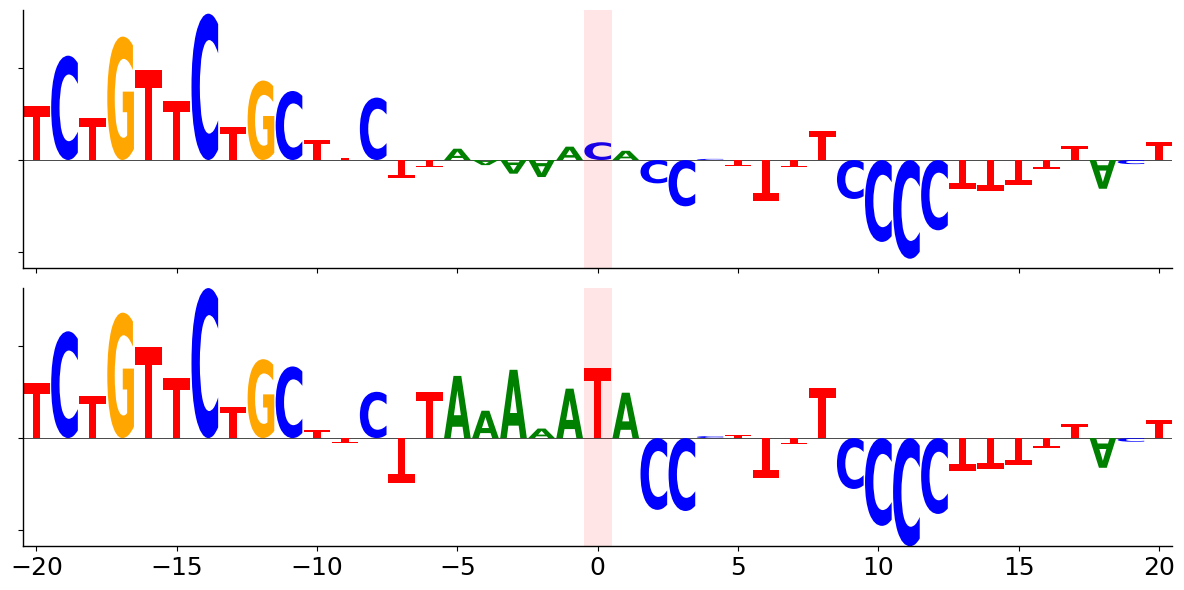

Running rs13025765
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


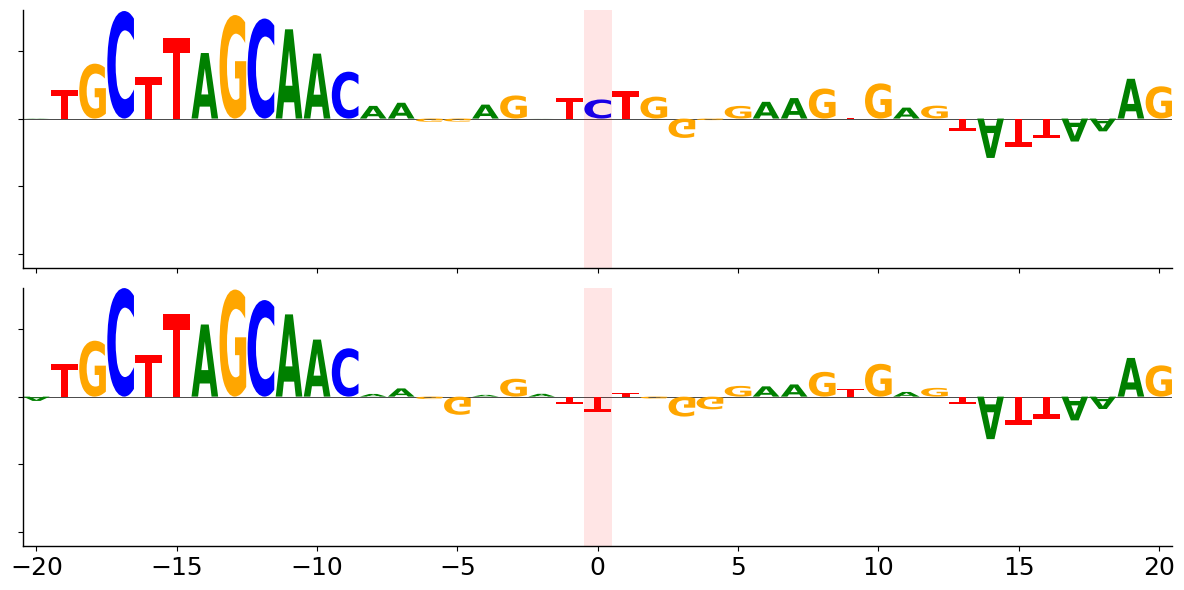

Running rs13025717
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


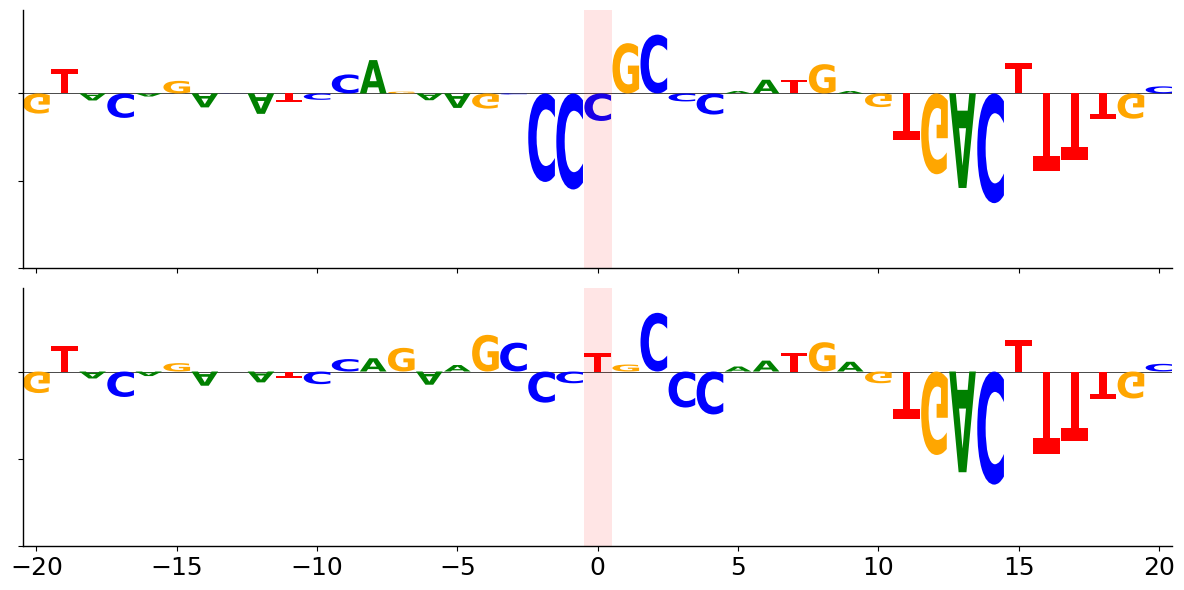

Running rs72838288
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


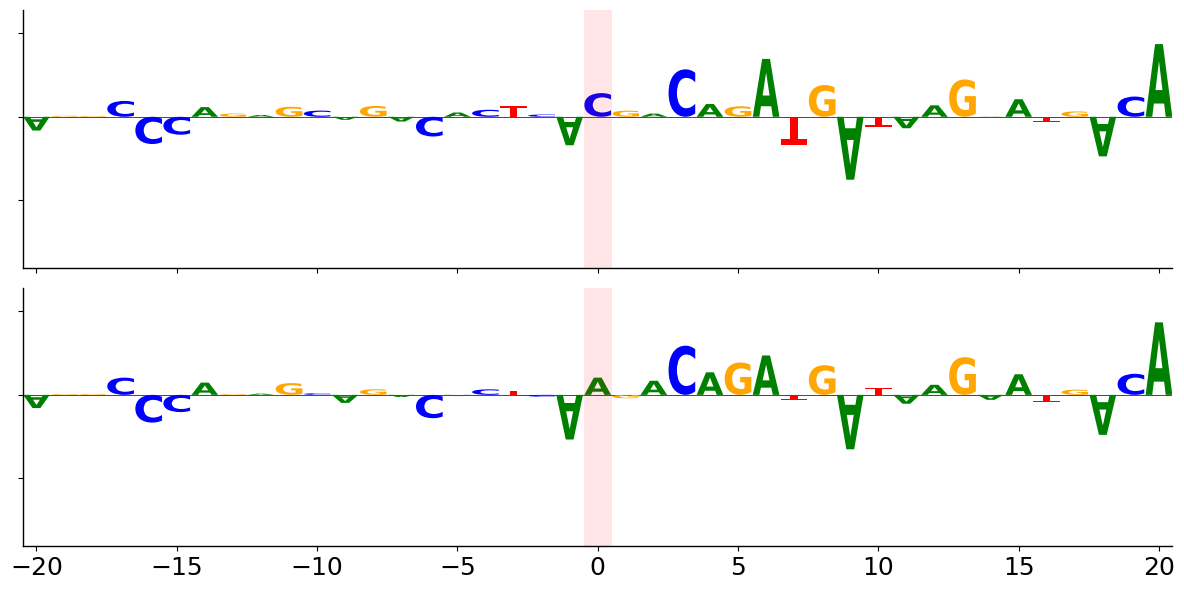

Running rs73972710
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


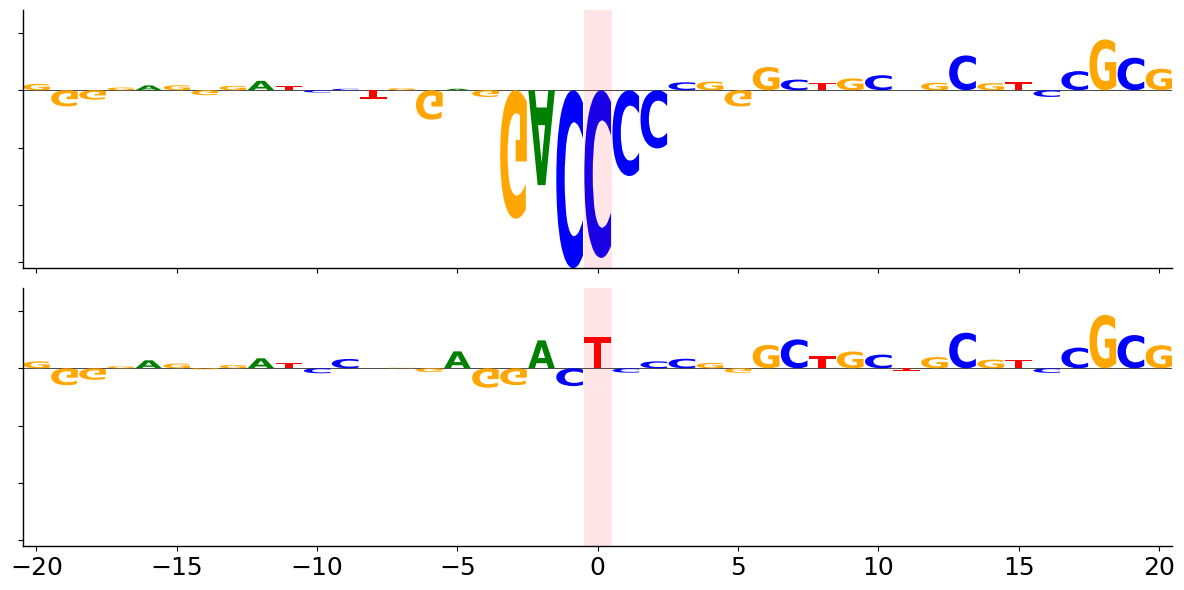

Running rs12721109
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


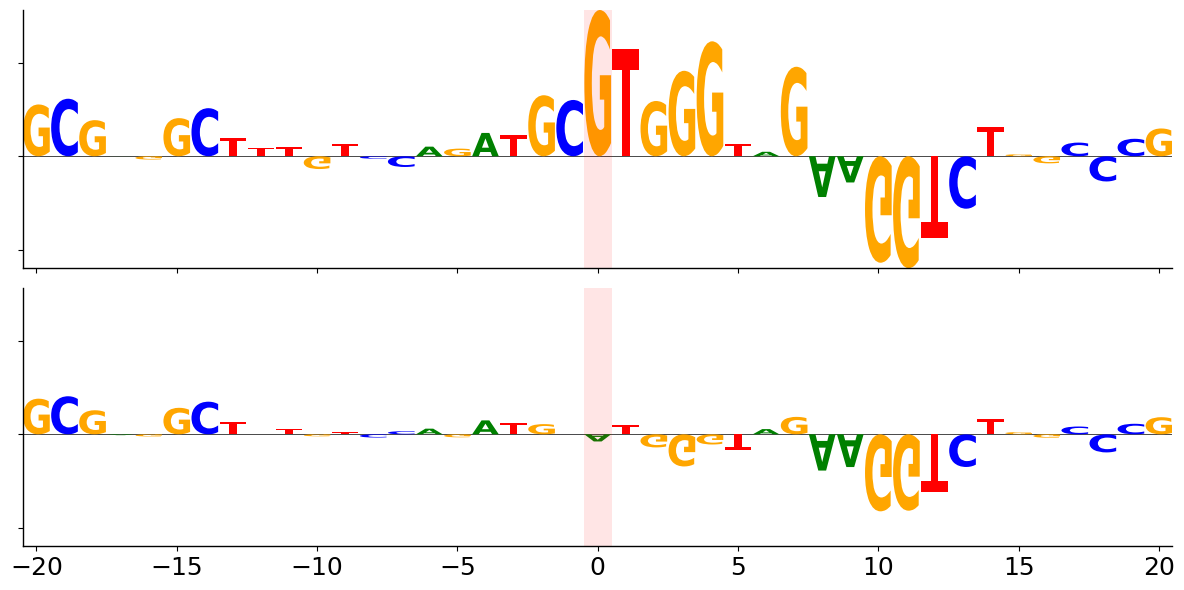

Running rs9270833
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


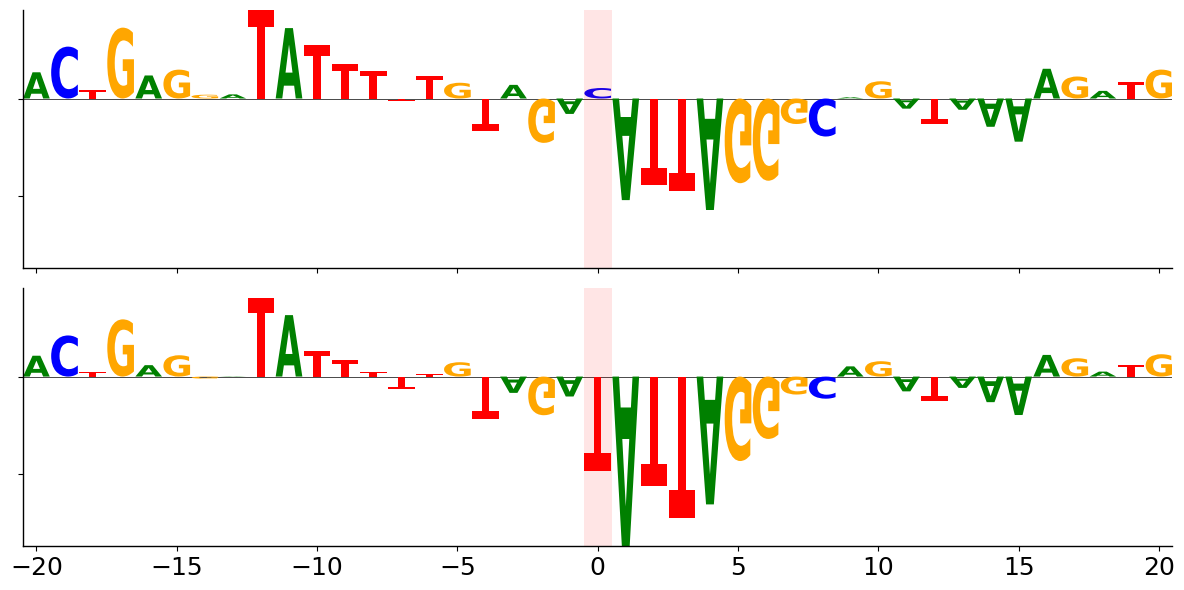

Running rs9271162
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


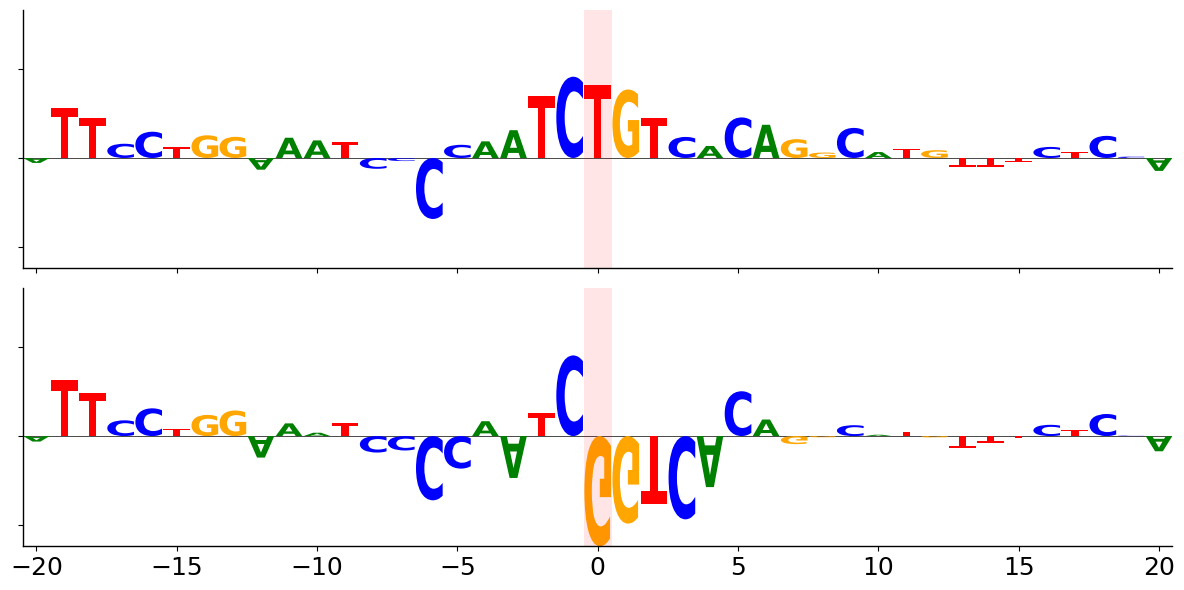

Running rs3104416
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


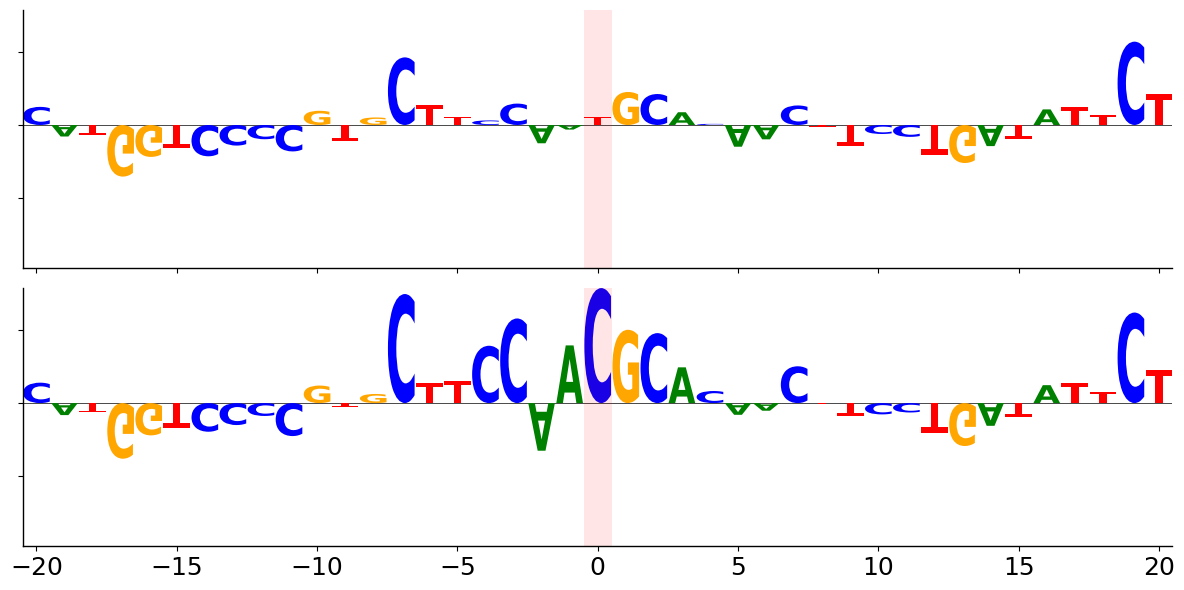

Running rs636317
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


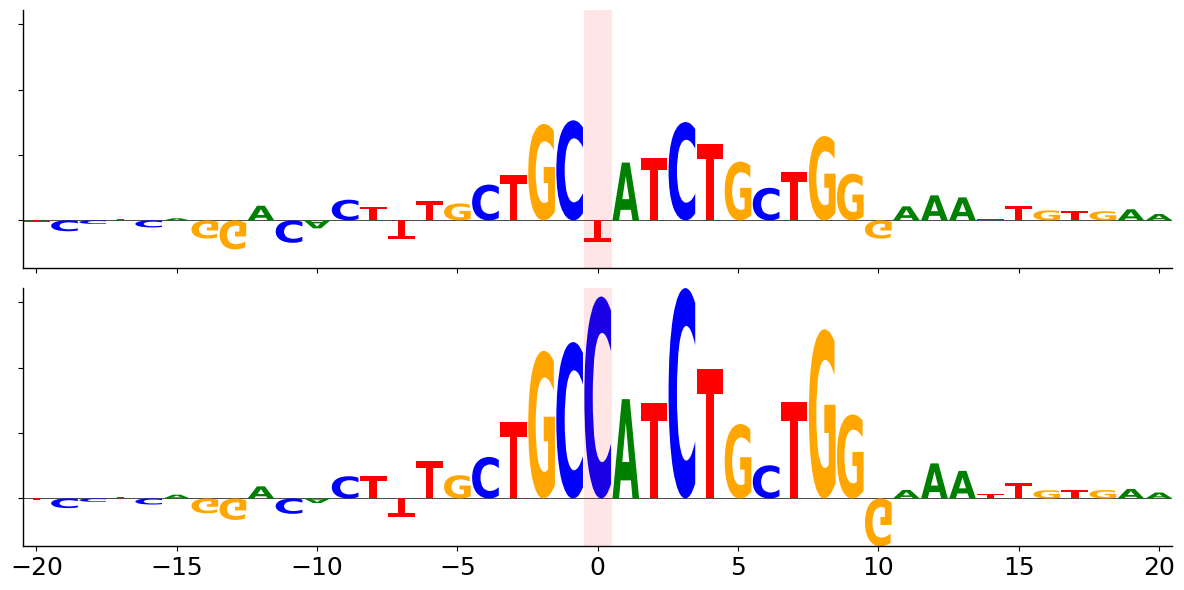

Running rs147038704
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


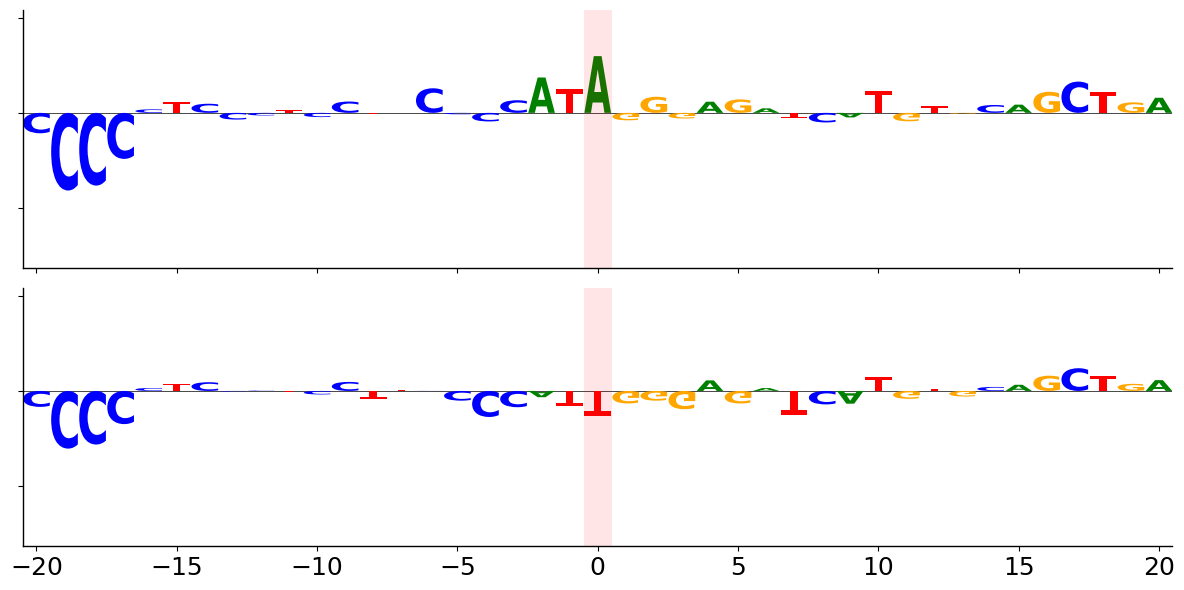

Running rs115607757
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


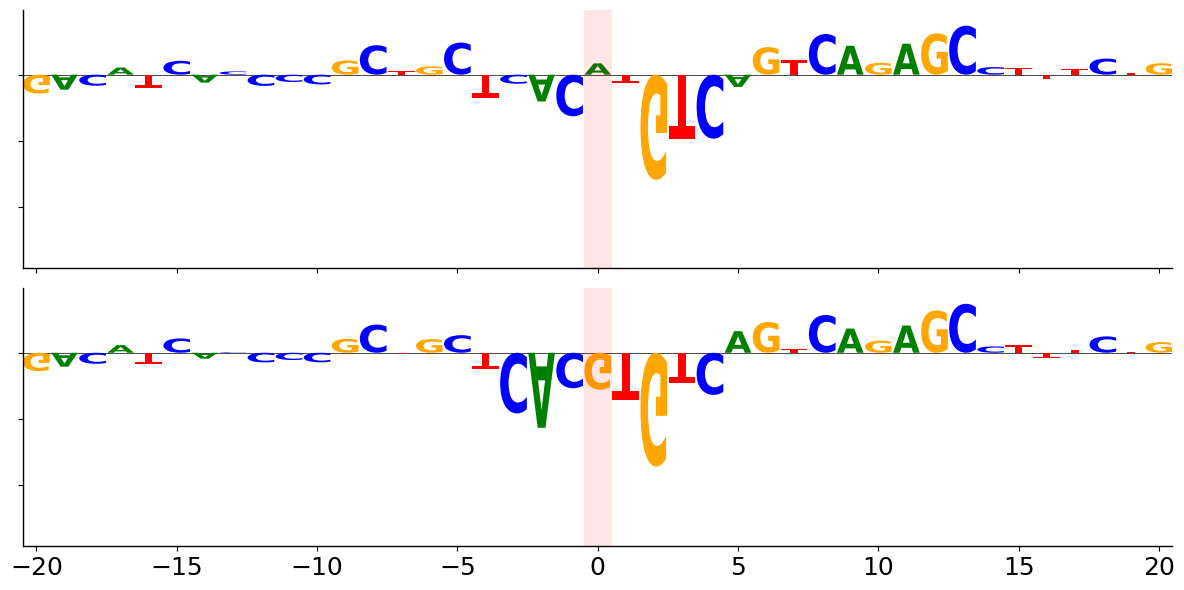

Running rs62427420
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


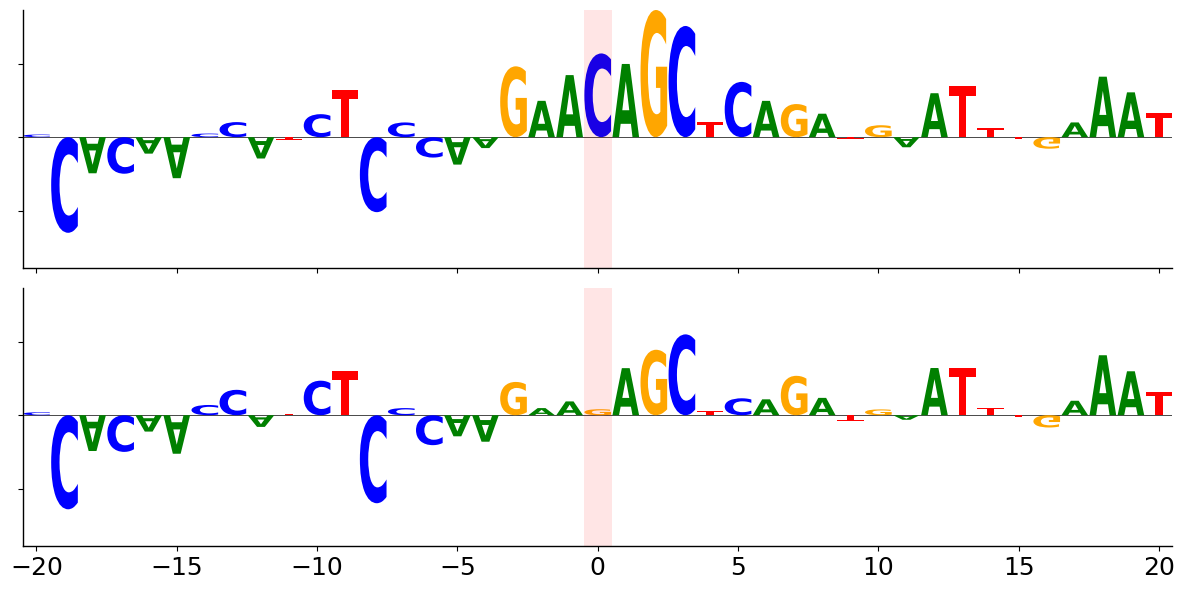

Running rs189835276
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


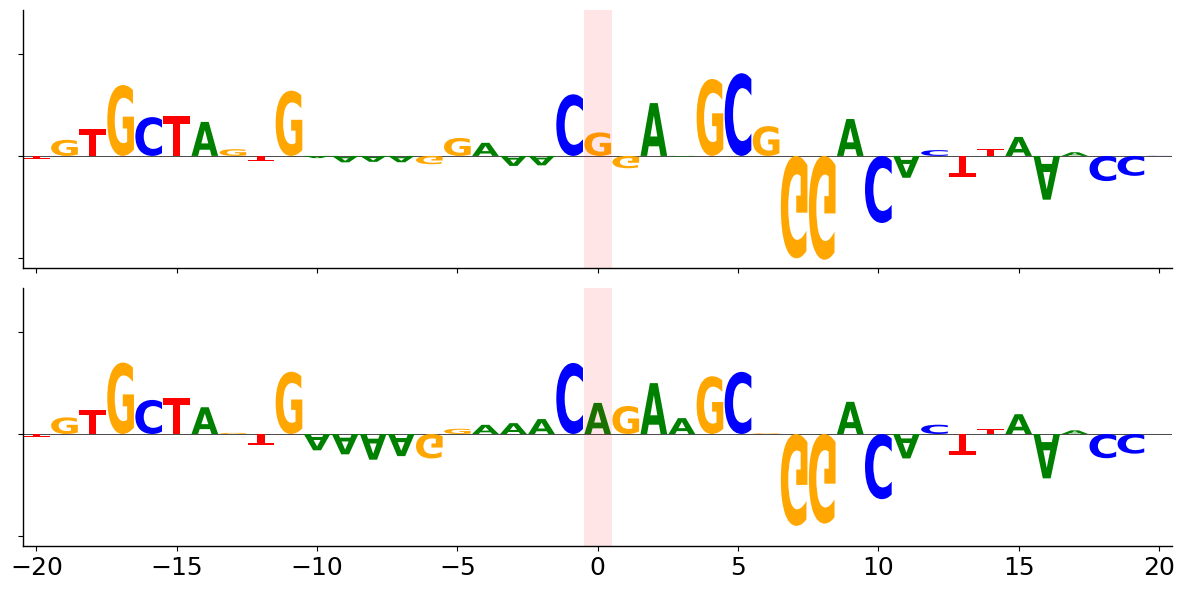

Running rs73278954
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


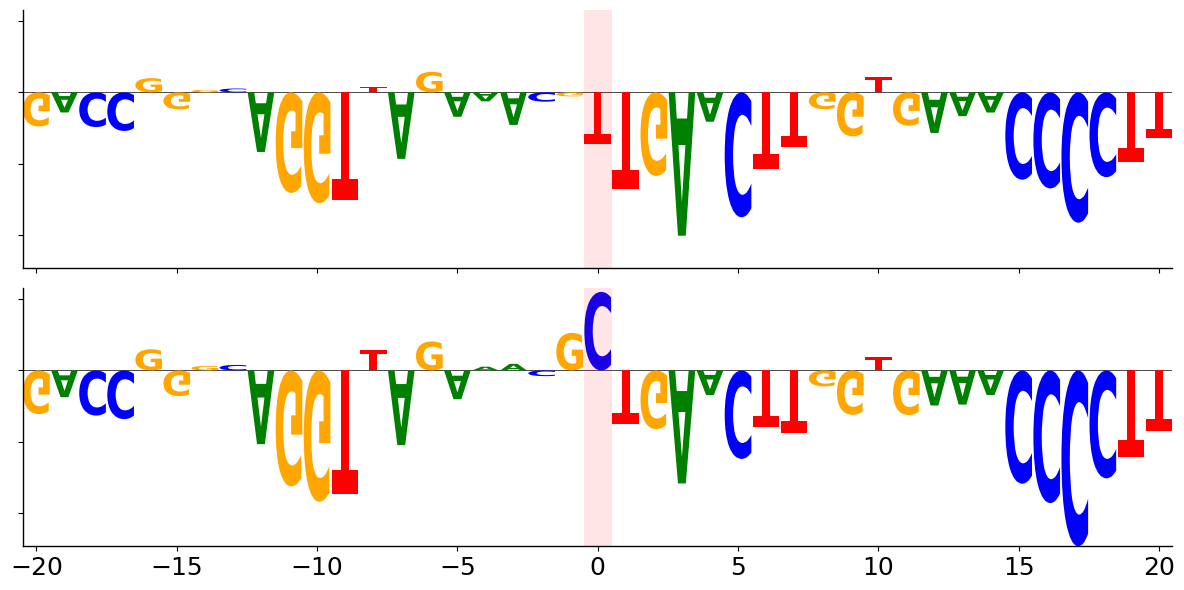

Running rs113838039
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


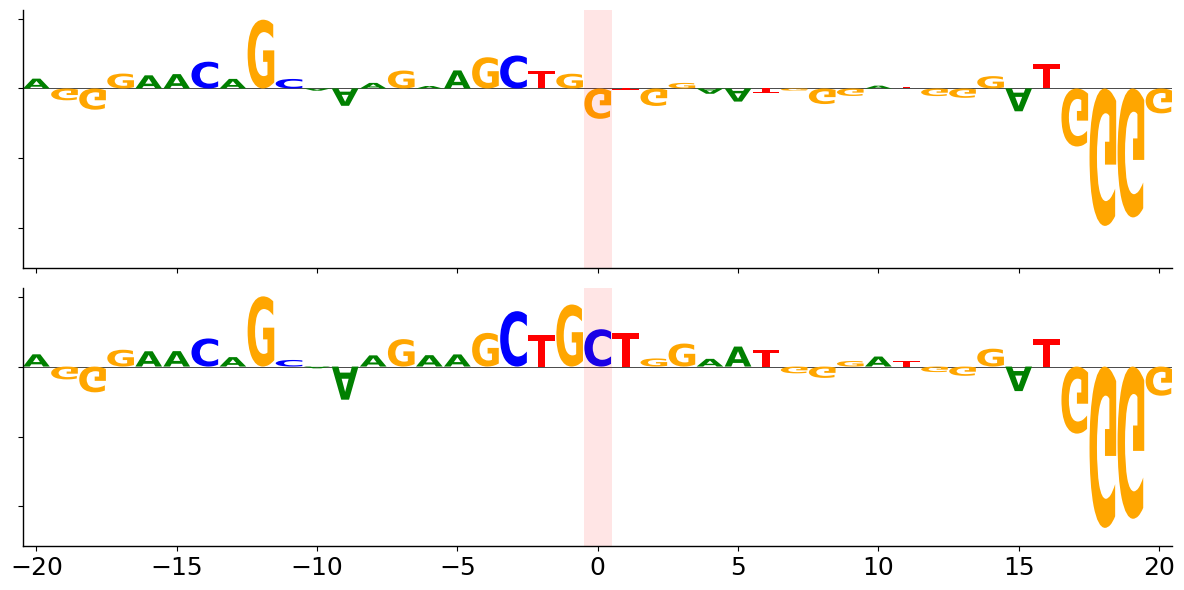

Running rs1376126
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


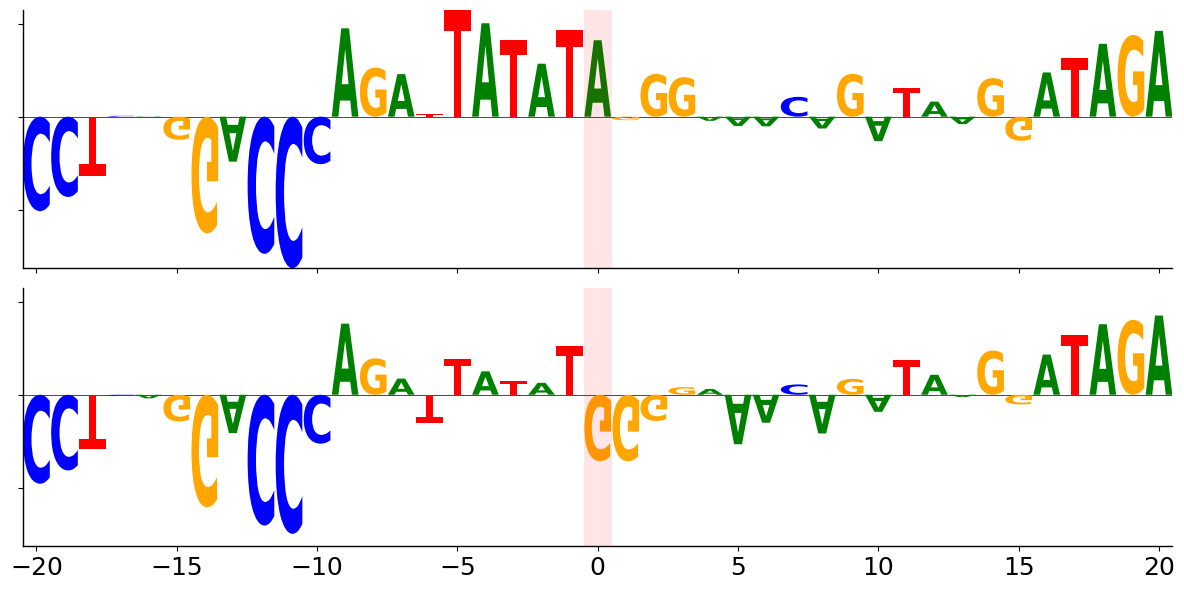

Running rs143882939
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


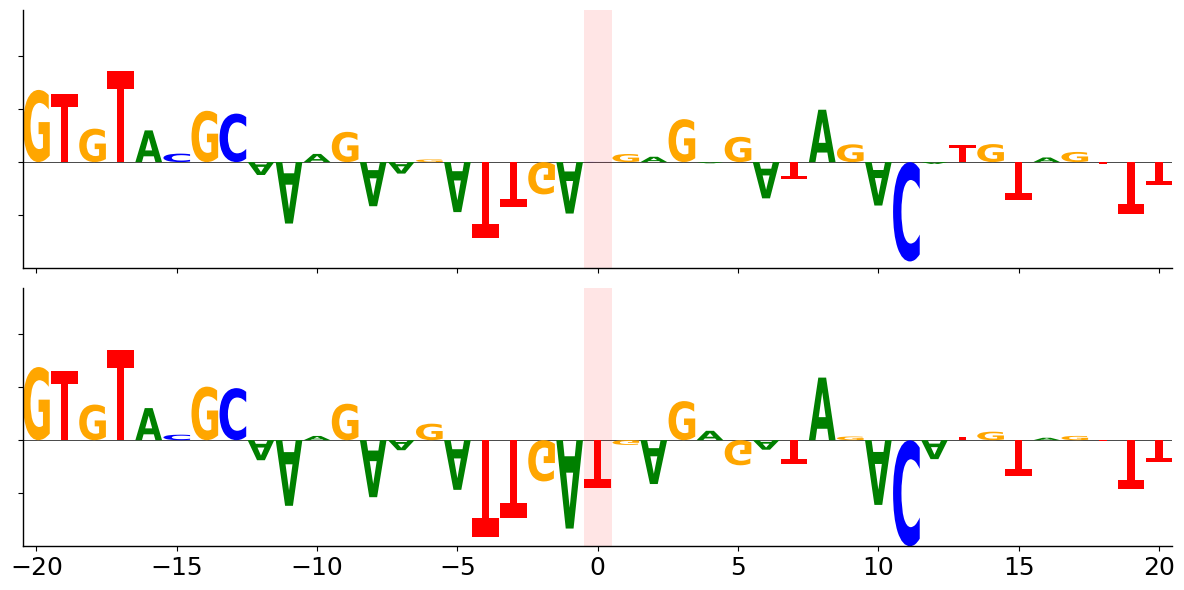

Running rs10792265
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


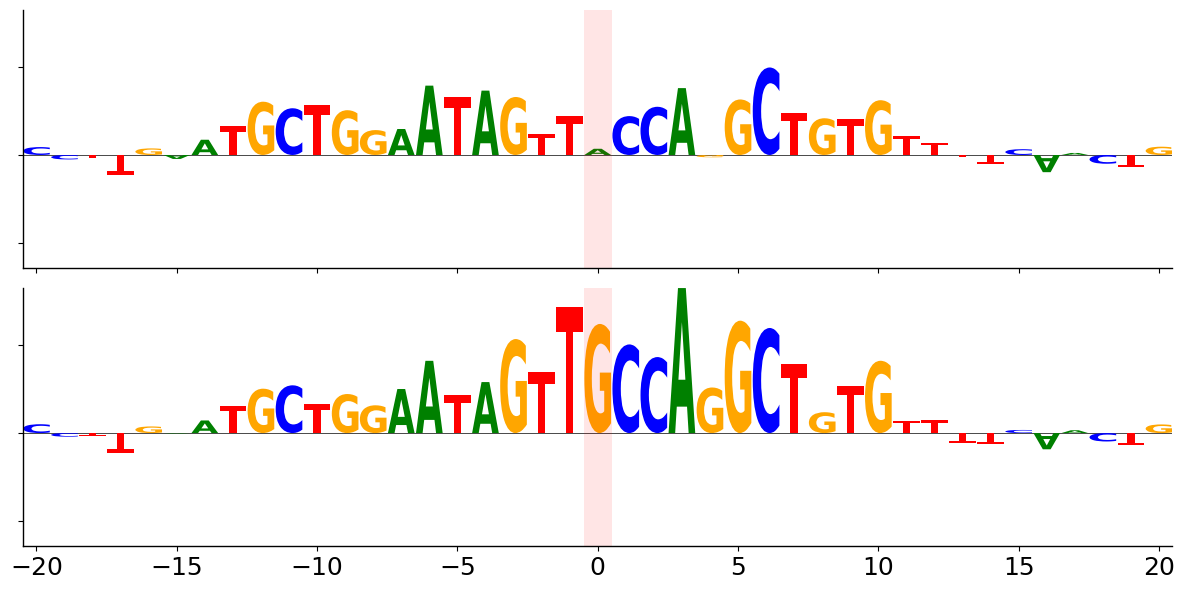

Running rs10897049
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


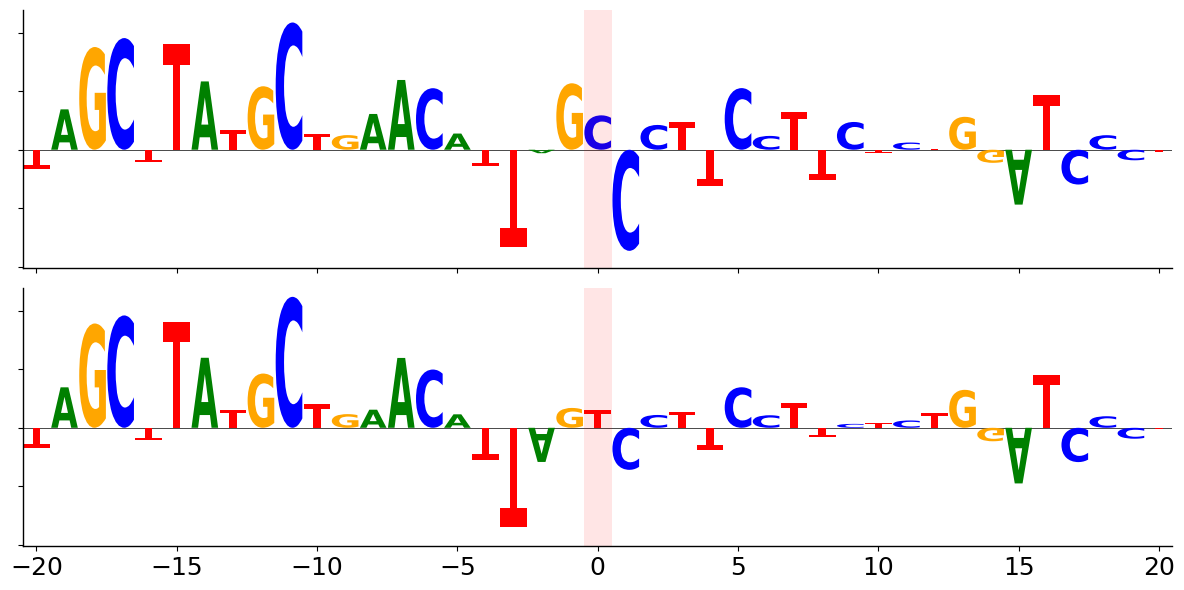

Running rs4477457
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


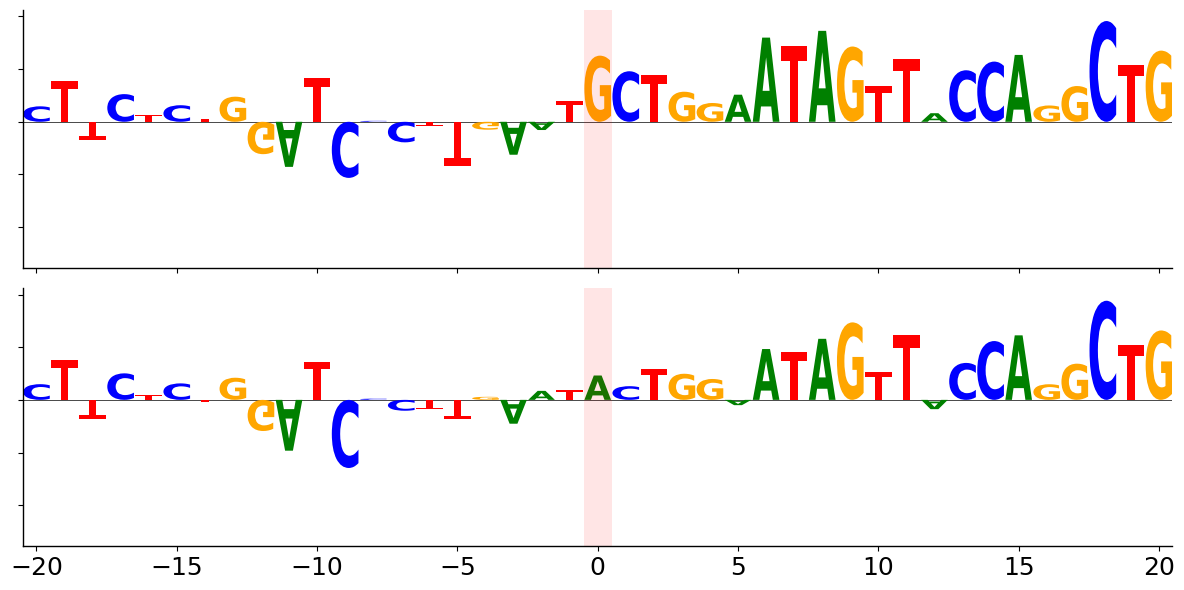

Running rs6363560
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


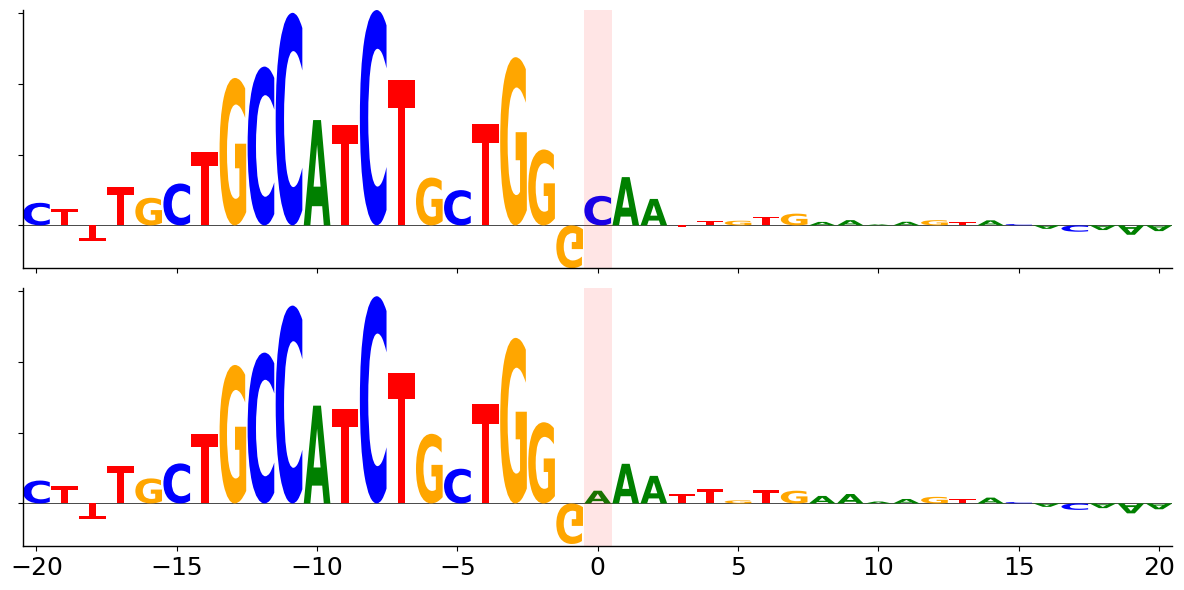

Running rs672399
Selected neuron model(s):
  - fullard_DLPFC-model-best_SHAP

Pairwise delta-SHAP correlations in similarity window:
                               fullard_DLPFC-model-best_SHAP
fullard_DLPFC-model-best_SHAP                            1.0


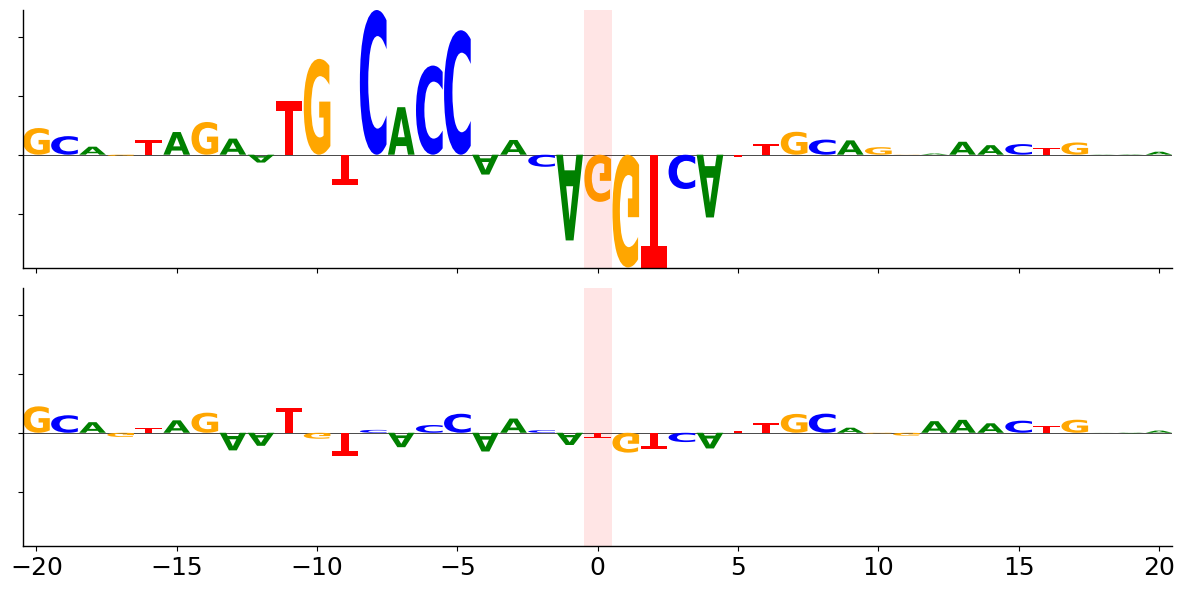

,rsid,selected_models,excluded_models
0,rs6733839,fullard_DLPFC-model-best_SHAP,
1,rs13025765,fullard_DLPFC-model-best_SHAP,
2,rs13025717,fullard_DLPFC-model-best_SHAP,
3,rs72838288,fullard_DLPFC-model-best_SHAP,
4,rs73972710,fullard_DLPFC-model-best_SHAP,
5,rs12721109,fullard_DLPFC-model-best_SHAP,
6,rs9270833,fullard_DLPFC-model-best_SHAP,
7,rs9271162,fullard_DLPFC-model-best_SHAP,
8,rs3104416,fullard_DLPFC-model-best_SHAP,
9,rs636317,fullard_DLPFC-model-best_SHAP,


In [6]:
# ============================================================
# Auto-consensus SHAP main figures for SNPs plotted in 6.logo_deepshap.ipynb
# Loop version
# ============================================================

COMMON_KWARGS = dict(
    start=-20,
    end=20,
    neuron_models=DEFAULT_NEURON_MODELS,
    similarity_window=(-10, 10),
    min_subset_size=2,
    tick_fontsize=18,
    figure_size=(12, 6),
    snp_position=0,
    verbose=True
)

neuron_snp_jobs = [
    # --------------------------------------------------------
    # 1. BIN1 / related loci
    # --------------------------------------------------------
    ("rs6733839",   576 - 1, int(1710 / 2 + 576 - 1)),
    ("rs13025765",  170,     int(1710 / 2 + 170)),
    ("rs13025717",  170 - 1, int(1710 / 2 + 170 - 1)),
    ("rs72838288",  615 - 1, int(1710 / 2 + 615 - 1)),
    ("rs73972710",  641 - 1, int(1710 / 2 + 641 - 1)),

    # --------------------------------------------------------
    # 2. HLA / immune-neural shared loci
    # --------------------------------------------------------
    ("rs12721109",  164,     int(1710 / 2 + 164)),
    ("rs9270833",   776,     int(1710 / 2 + 776)),
    ("rs9271162",   829,     int(1710 / 2 + 829)),
    ("rs3104416",   372,     int(1710 / 2 + 372)),
    ("rs636317",    557 - 1, int(1710 / 2 + 557 - 1)),

    # --------------------------------------------------------
    # 3. SEC63 locus
    # --------------------------------------------------------
    ("rs147038704", 221 - 1, int(1710 / 2 + 221 - 1)),
    ("rs115607757", 113 - 1, int(1710 / 2 + 113 - 1)),
    ("rs62427420",  554 - 1, int(1710 / 2 + 554 - 1)),
    ("rs189835276", 316 - 1, int(1710 / 2 + 316 - 1)),

    # --------------------------------------------------------
    # 4. DBX2 / NELL2 locus
    # --------------------------------------------------------
    ("rs73278954",  628 - 1, int(1710 / 2 + 628 - 1)),
    ("rs113838039", 93 - 1,  int(1710 / 2 + 93 - 1)),
    ("rs1376126",   176 - 1, int(1710 / 2 + 176 - 1)),
    ("rs143882939", 207 - 1, int(1710 / 2 + 207 - 1)),

    # --------------------------------------------------------
    # 5. MS4A6A locus
    # --------------------------------------------------------
    ("rs10792265",  41 - 2,  int(1710 / 2 + 41 - 2)),
    ("rs10897049",  52 - 2,  int(1710 / 2 + 52 - 2)),
    ("rs4477457",   428 - 2, int(1710 / 2 + 428 - 2)),

    # --------------------------------------------------------
    # 6. MS4A4A locus
    # --------------------------------------------------------
    ("rs6363560",   560 - 2, int(1710 / 2 + 560 - 2)),
    ("rs672399",    576 - 2, int(1710 / 2 + 576 - 2)),
]

all_results = {}

for rsid, major_idx, minor_idx in neuron_snp_jobs:
    print(f"Running {rsid}")
    result = plot_auto_consensus_main_figure(
        major_index=major_idx,
        minor_index=minor_idx,
        output_file=f'{rsid}_neuron_auto_consensus_main.pdf',
        **COMMON_KWARGS
    )
    all_results[rsid] = result

summary_df = pd.DataFrame({
    'rsid': list(all_results.keys()),
    'selected_models': [
        ', '.join(v['selected_models']) for v in all_results.values()
    ],
    'excluded_models': [
        ', '.join(v['excluded_models']) if len(v['excluded_models']) > 0 else ''
        for v in all_results.values()
    ]
})

summary_df

Running rs6733839
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


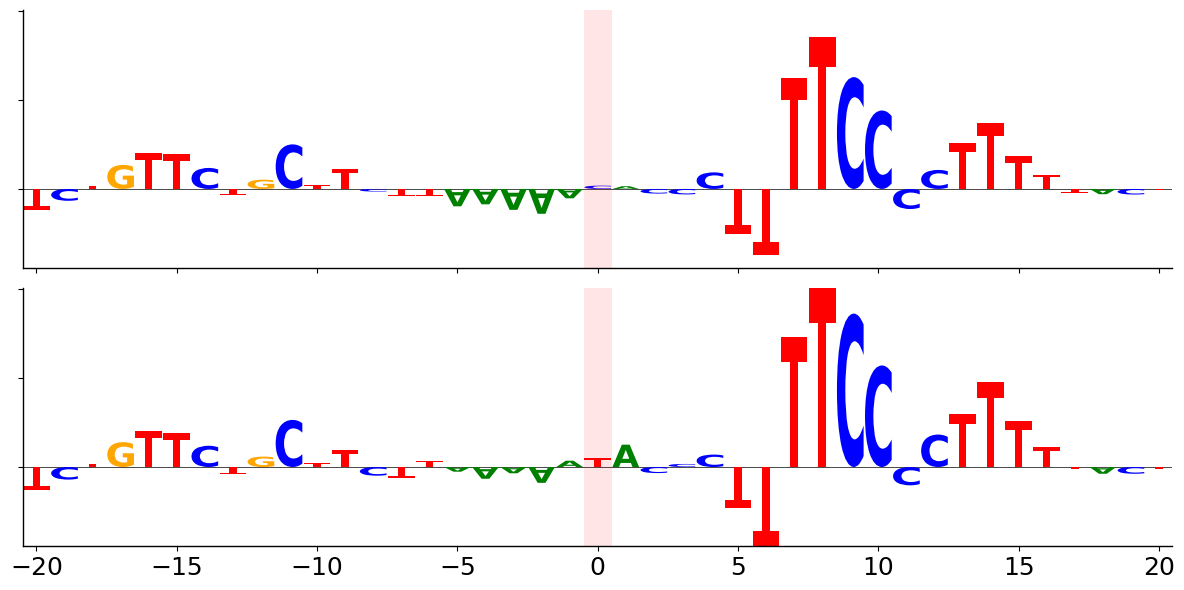

Running rs13025765
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


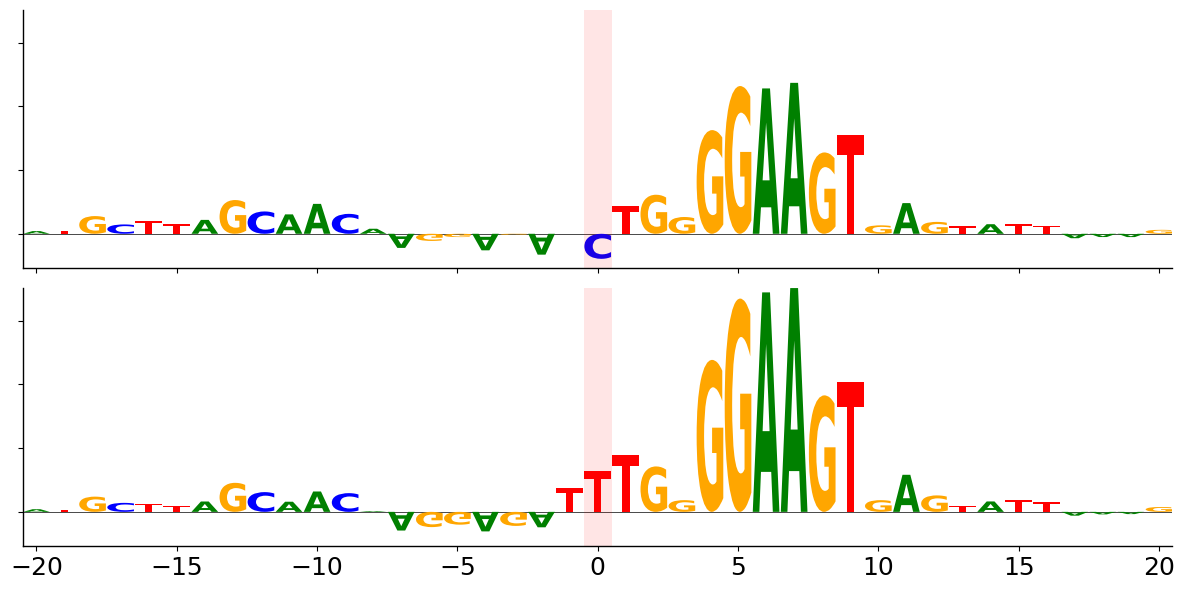

Running rs13025717
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


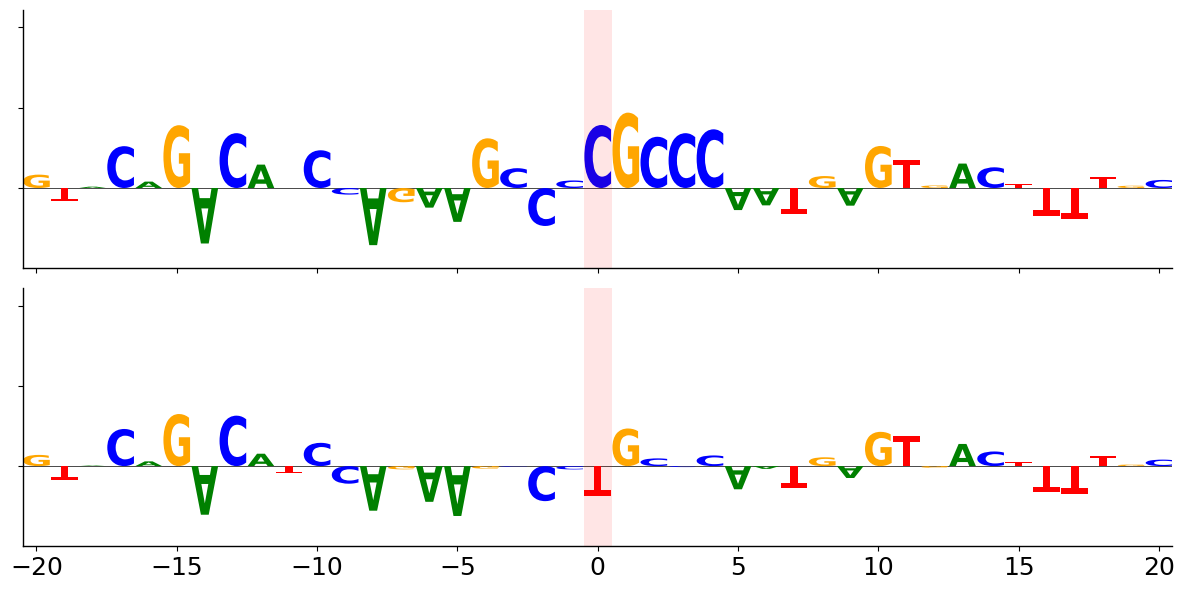

Running rs72838288
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


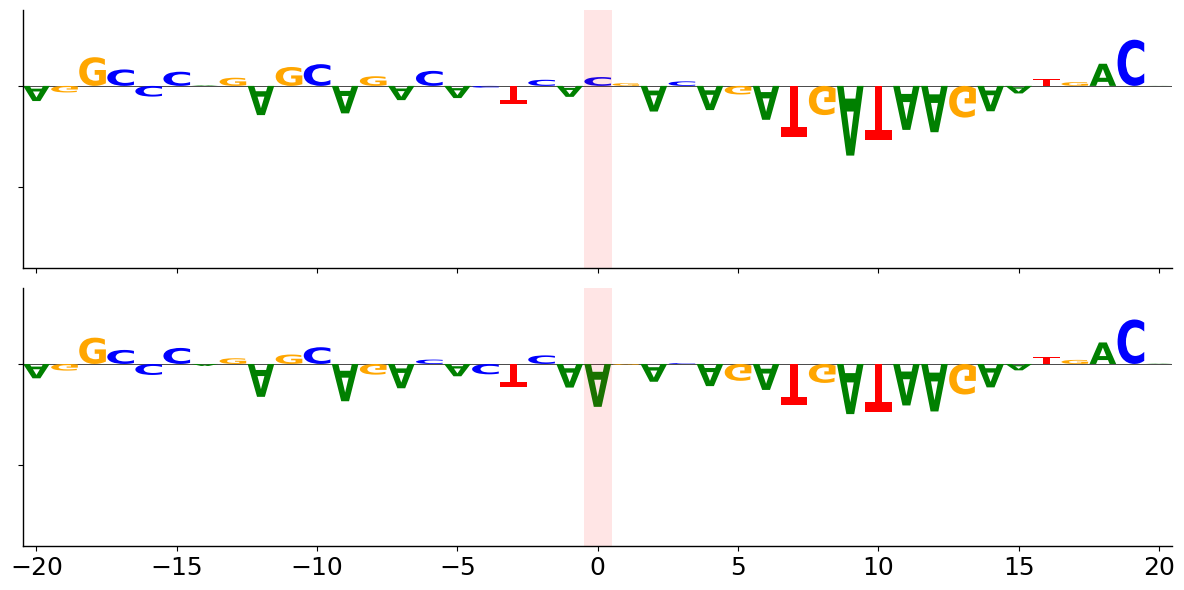

Running rs73972710
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


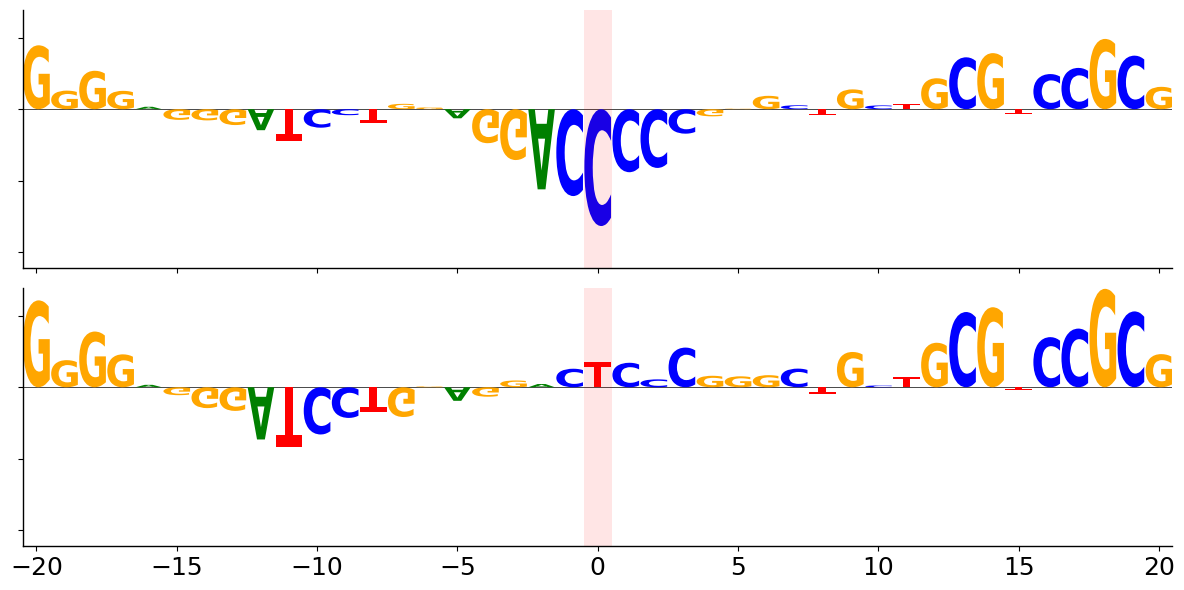

Running rs12721109
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


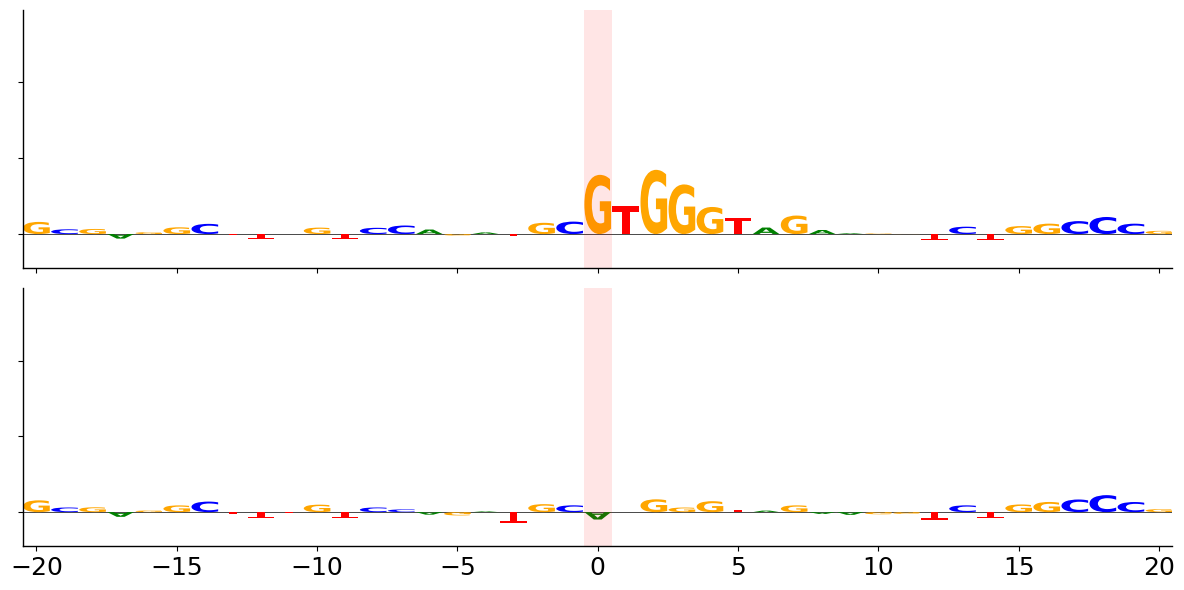

Running rs9270833
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


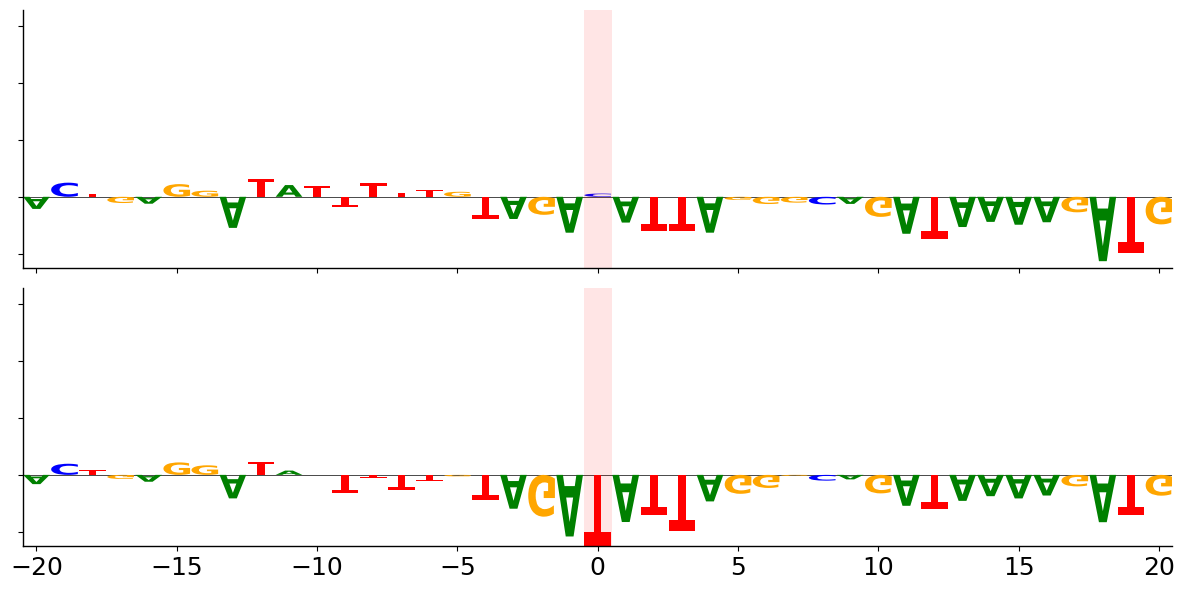

Running rs9271162
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


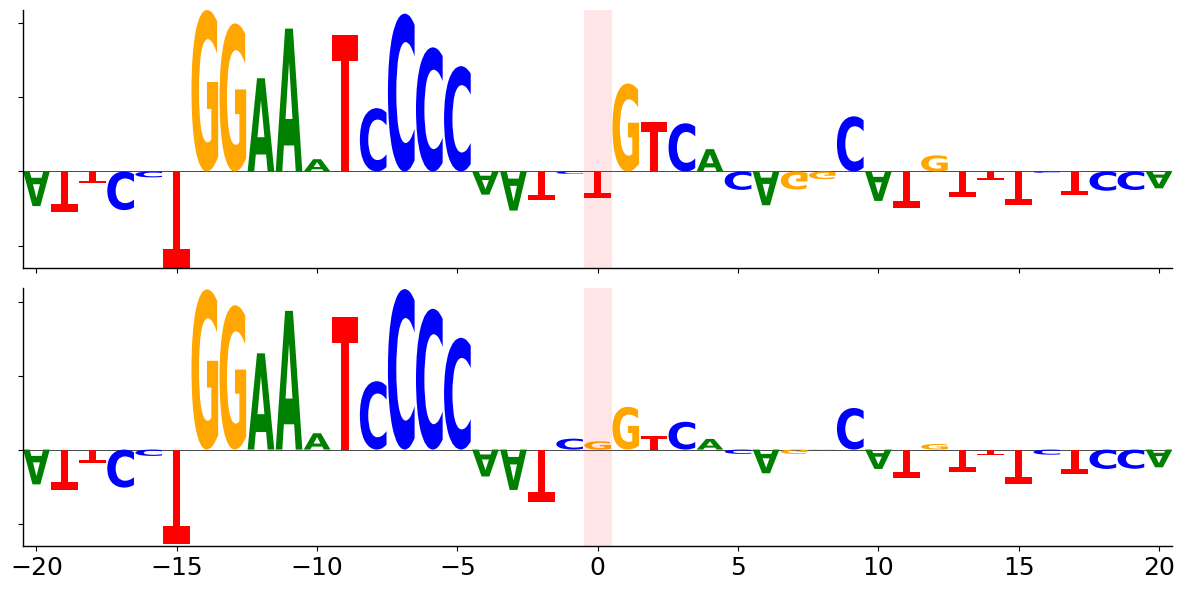

Running rs3104416
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


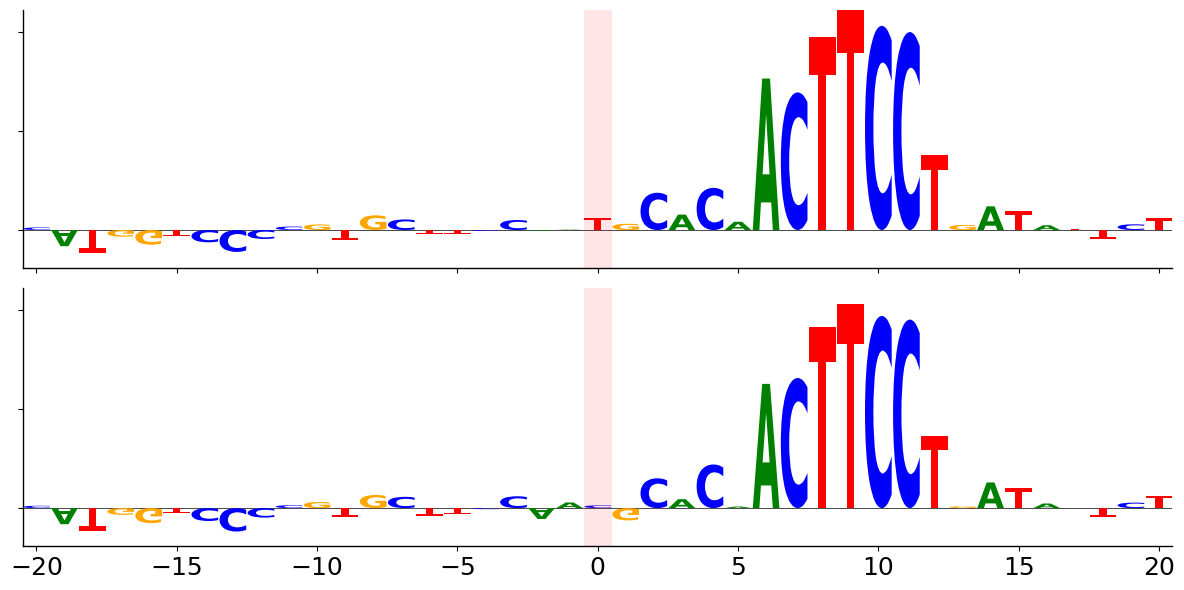

Running rs636317
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


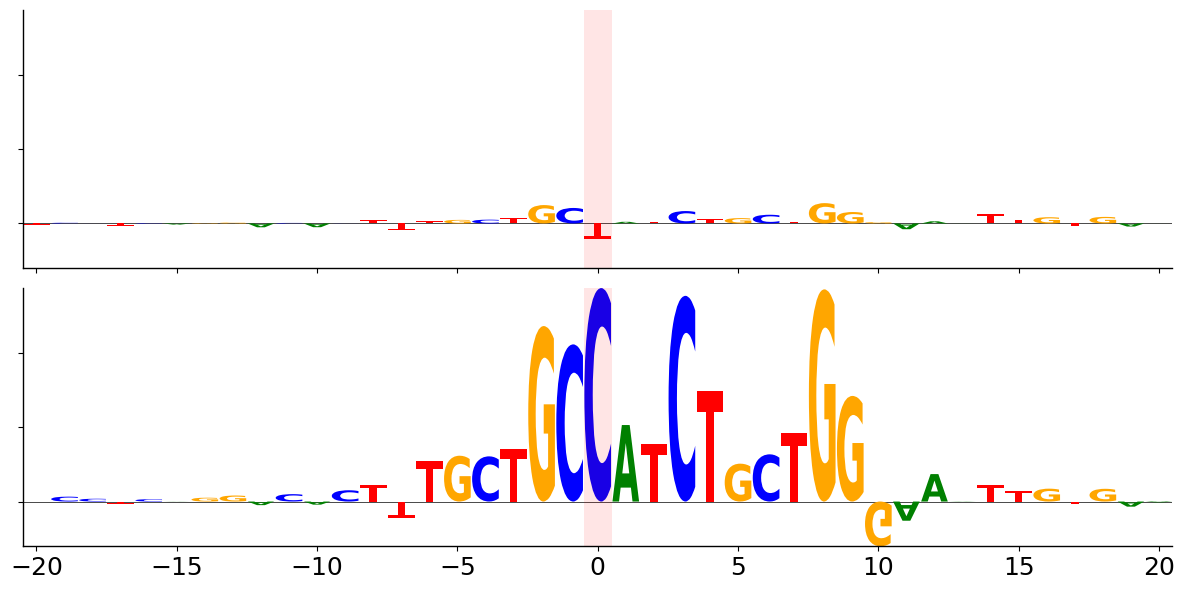

Running rs147038704
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


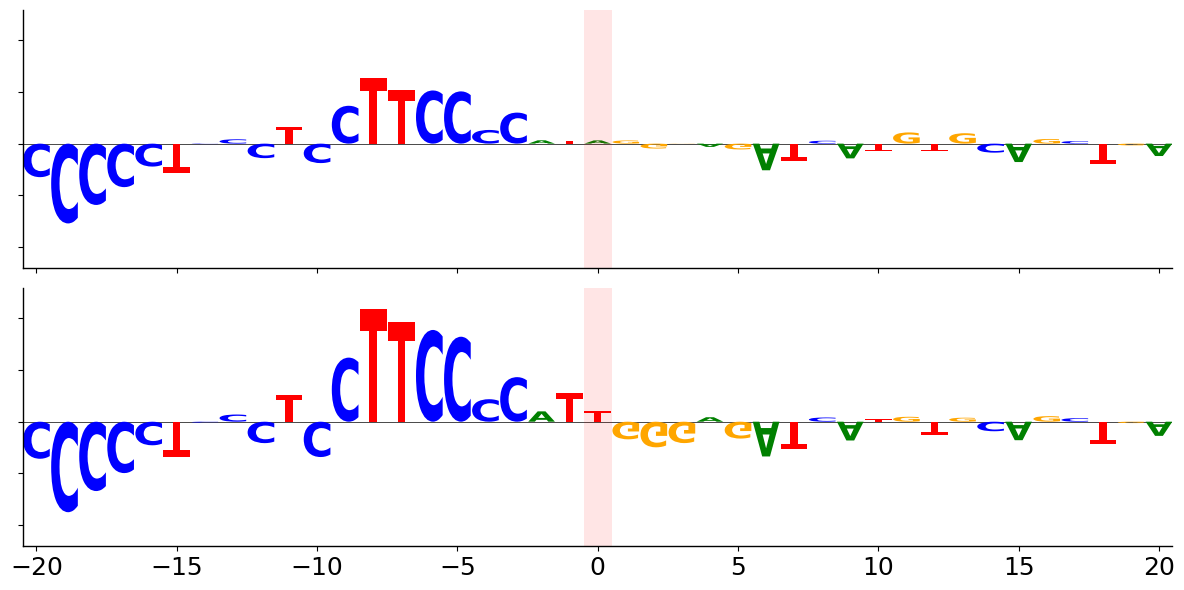

Running rs115607757
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


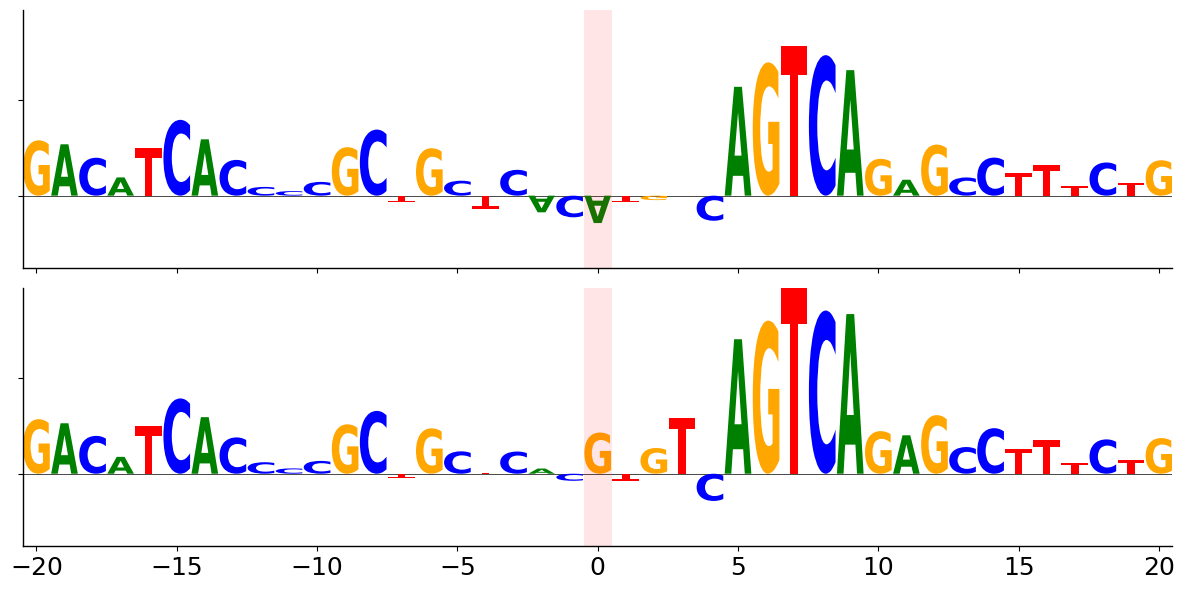

Running rs62427420
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


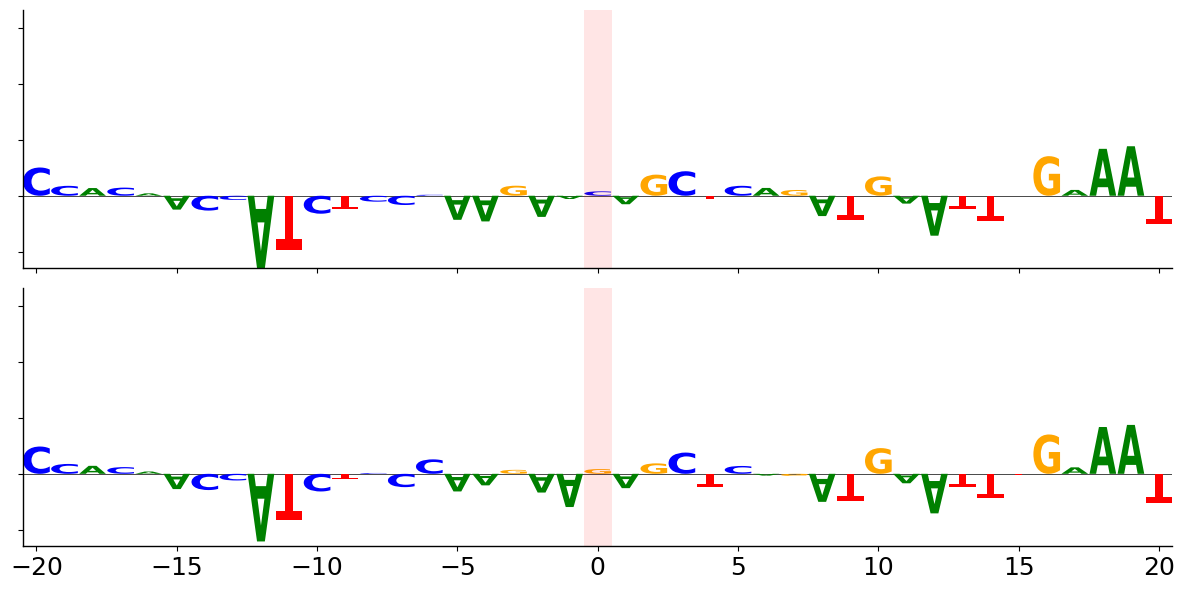

Running rs189835276
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


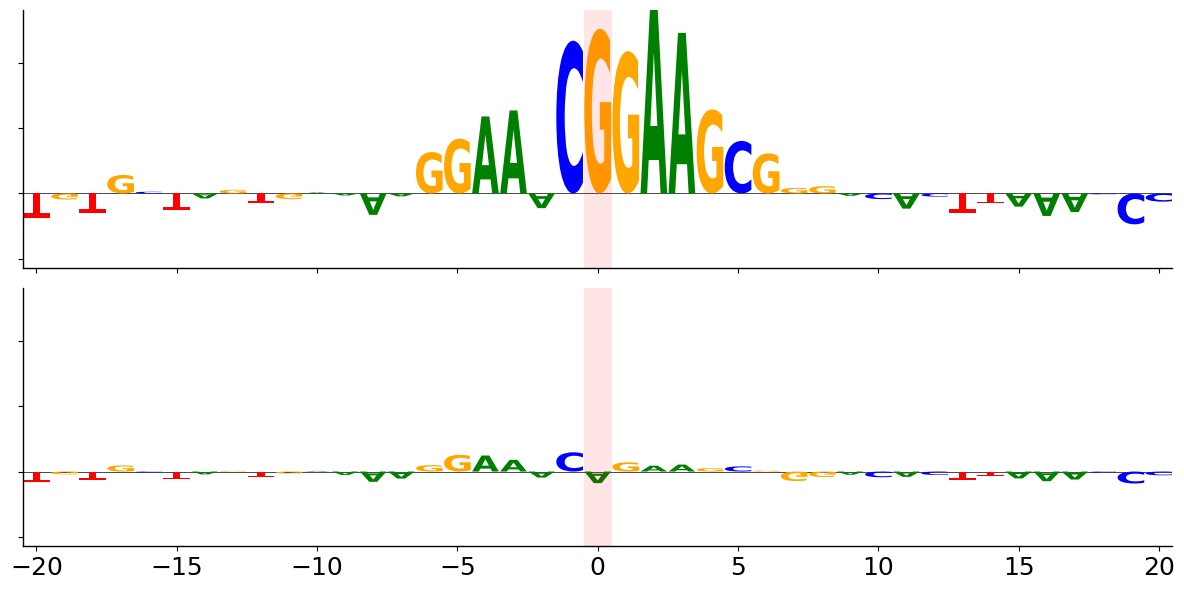

Running rs73278954
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


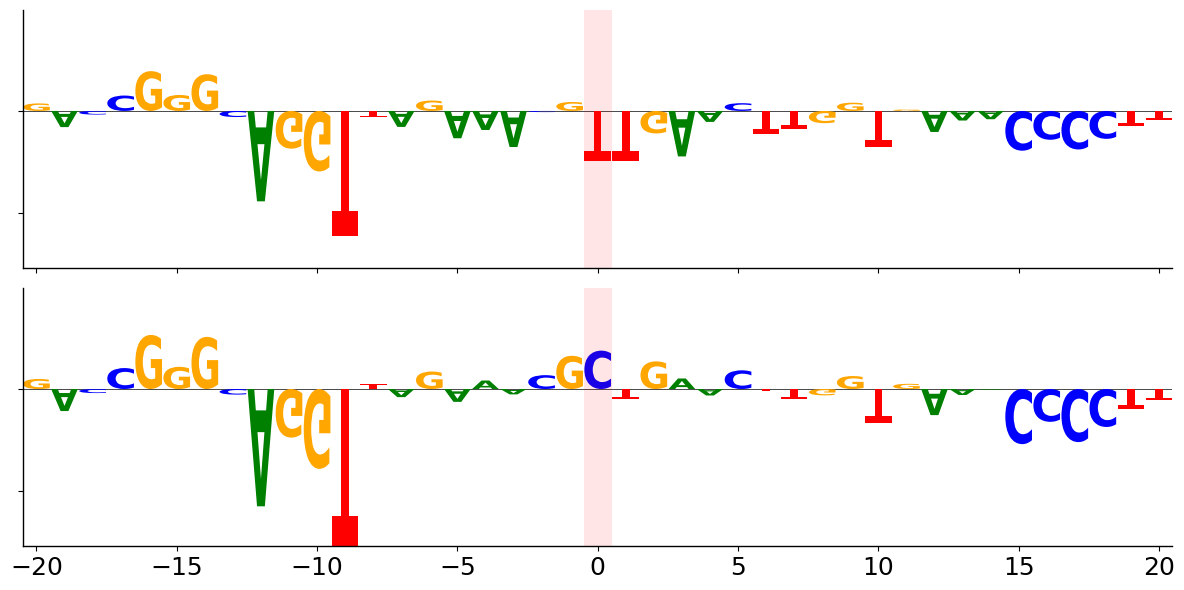

Running rs113838039
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


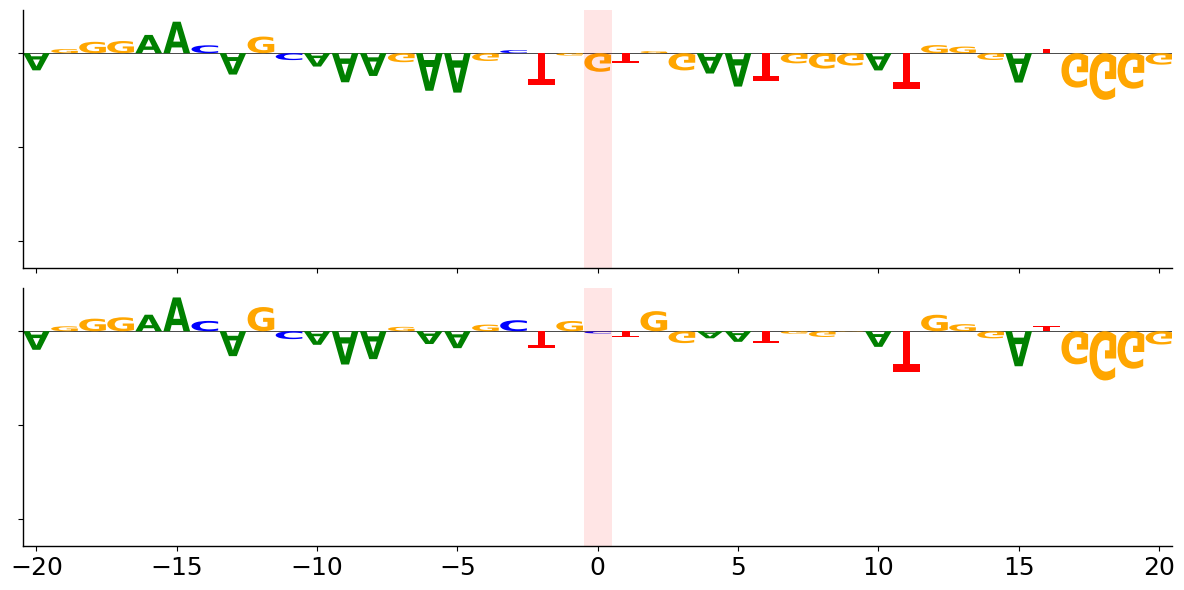

Running rs1376126
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


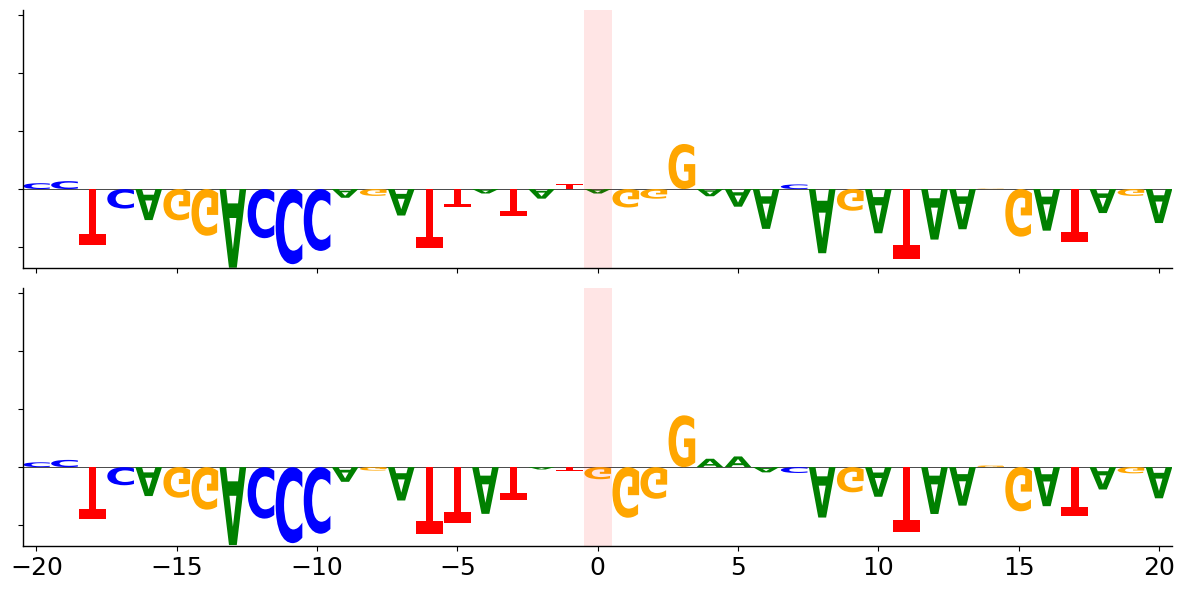

Running rs143882939
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


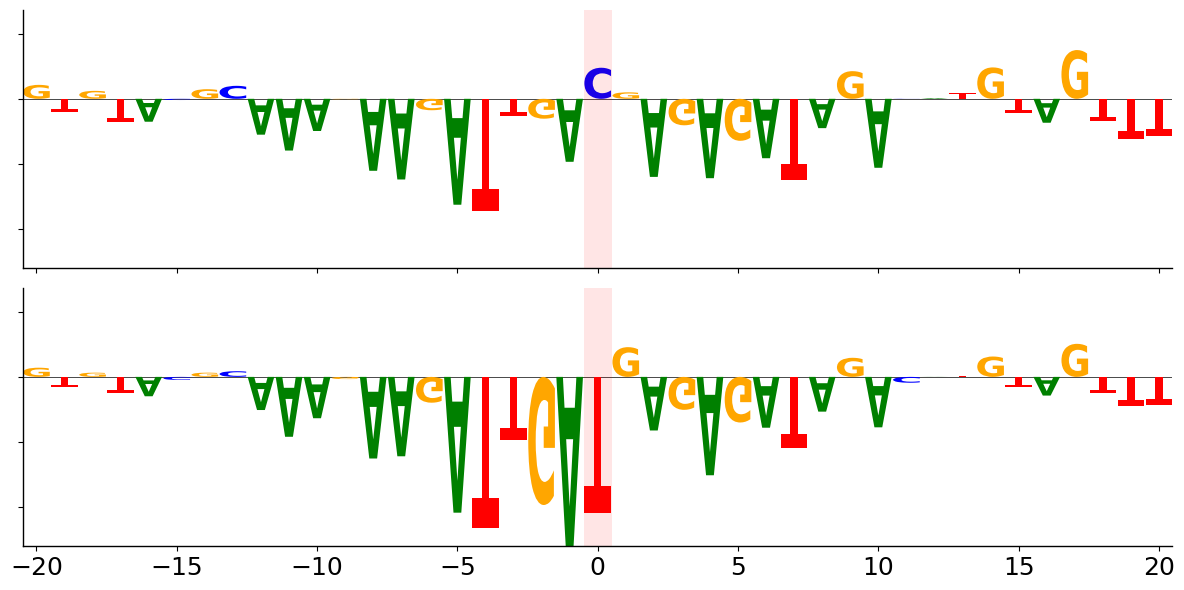

Running rs10792265
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


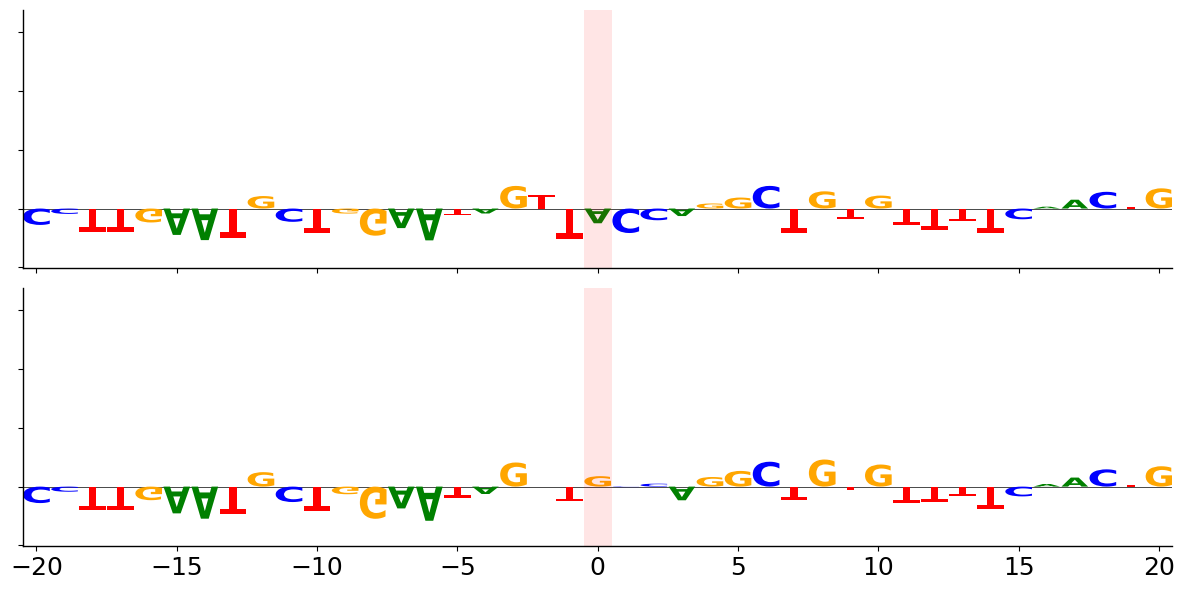

Running rs10897049
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


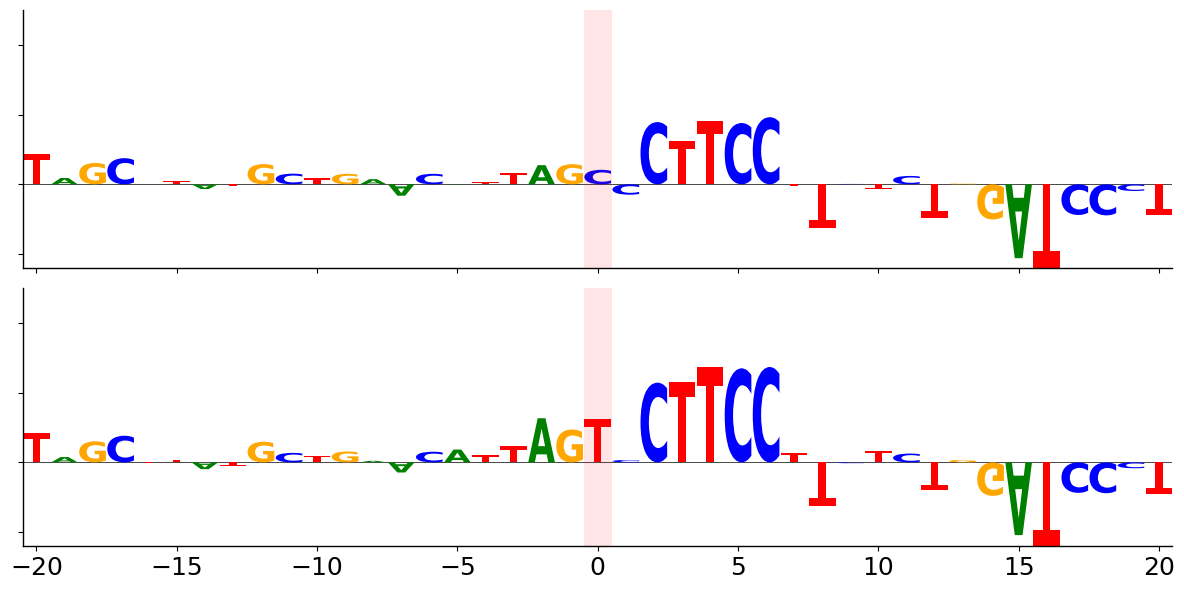

Running rs4477457
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


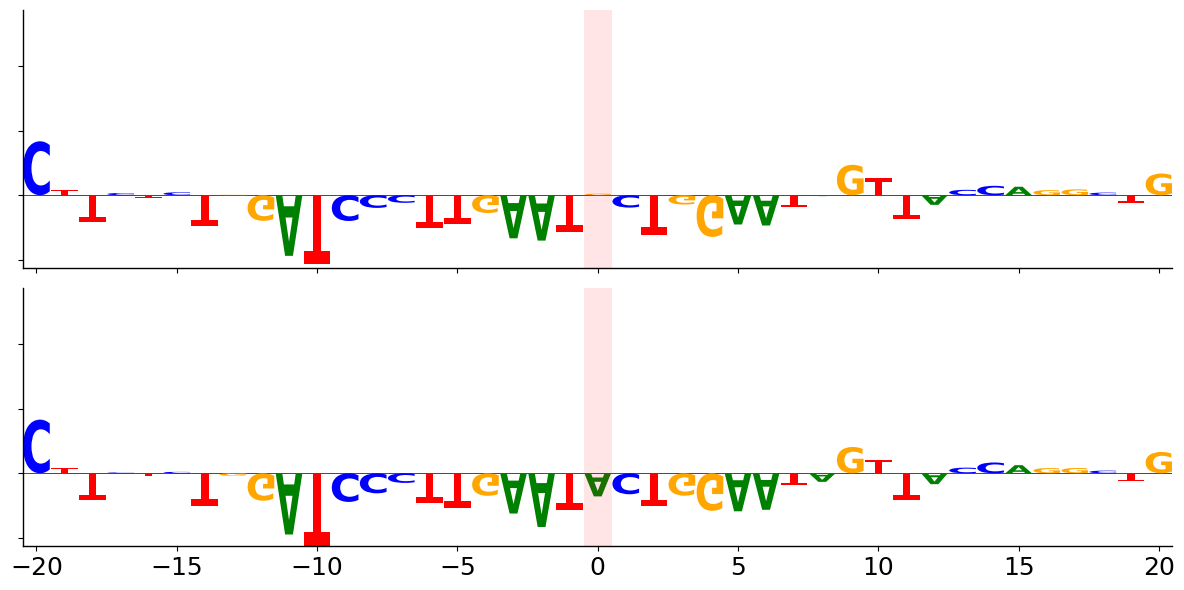

Running rs6363560
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


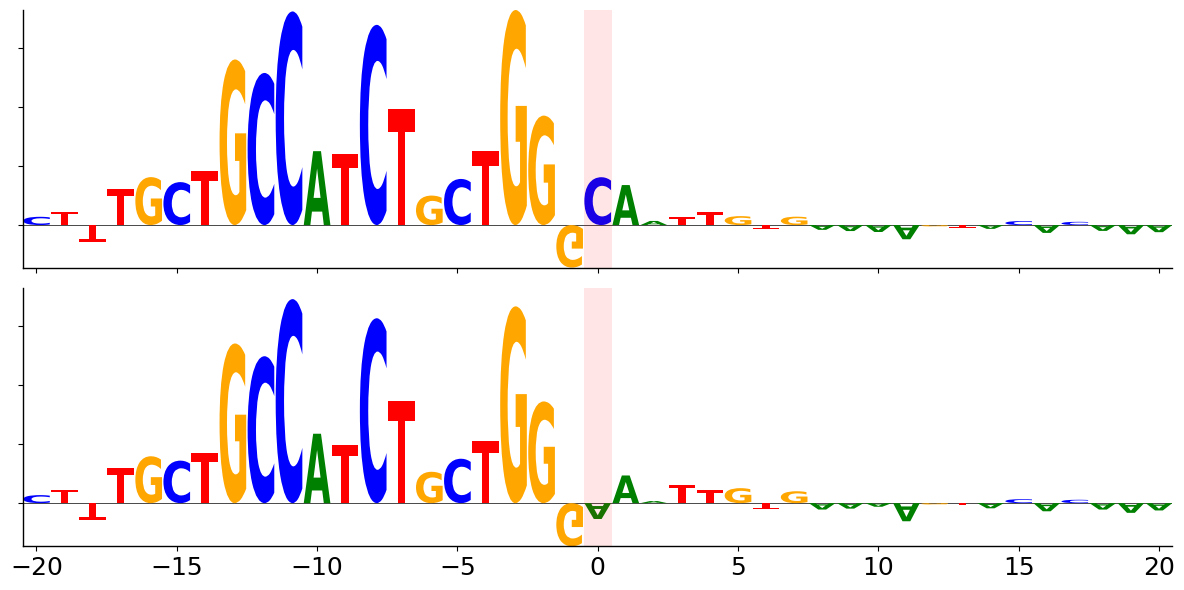

Running rs672399
Using THP-1 model(s):
  - THP1_Naive-model-best_SHAP


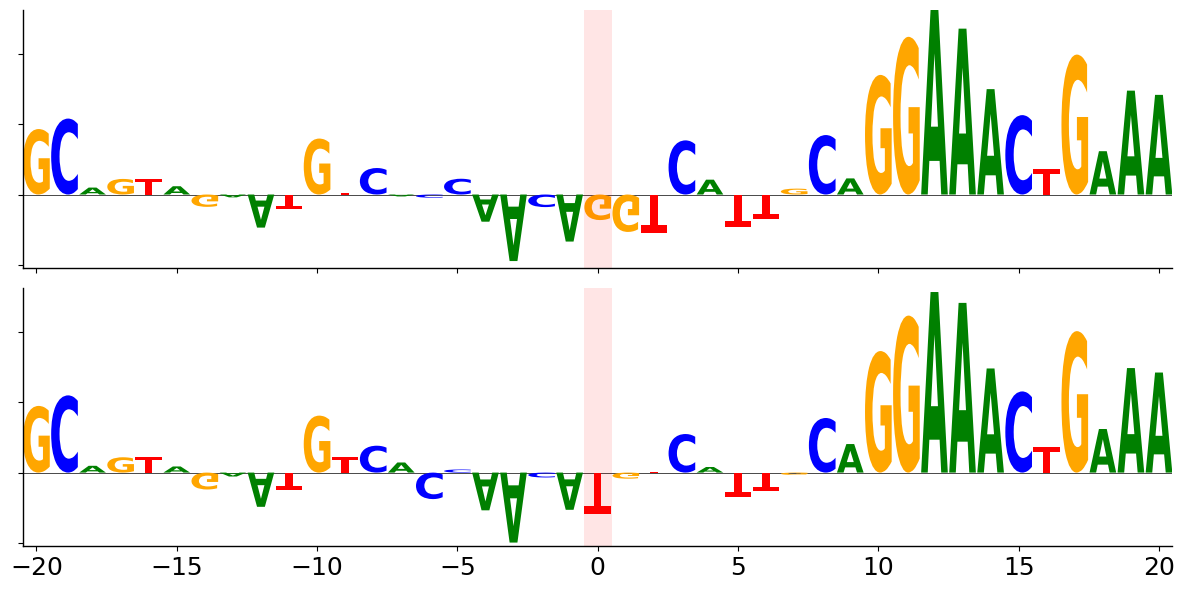

In [5]:
thp1_snp_jobs = [
    ("rs6733839",   576 - 1, int(1710 / 2 + 576 - 1)),
    ("rs13025765",  170,     int(1710 / 2 + 170)),
    ("rs13025717",  170 - 1, int(1710 / 2 + 170 - 1)),
    ("rs72838288",  615 - 1, int(1710 / 2 + 615 - 1)),
    ("rs73972710",  641 - 1, int(1710 / 2 + 641 - 1)),
    ("rs12721109",  164,     int(1710 / 2 + 164)),
    ("rs9270833",   776,     int(1710 / 2 + 776)),
    ("rs9271162",   829,     int(1710 / 2 + 829)),
    ("rs3104416",   372,     int(1710 / 2 + 372)),
    ("rs636317",    557 - 1, int(1710 / 2 + 557 - 1)),
    ("rs147038704", 221 - 1, int(1710 / 2 + 221 - 1)),
    ("rs115607757", 113 - 1, int(1710 / 2 + 113 - 1)),
    ("rs62427420",  554 - 1, int(1710 / 2 + 554 - 1)),
    ("rs189835276", 316 - 1, int(1710 / 2 + 316 - 1)),
    ("rs73278954",  628 - 1, int(1710 / 2 + 628 - 1)),
    ("rs113838039", 93 - 1,  int(1710 / 2 + 93 - 1)),
    ("rs1376126",   176 - 1, int(1710 / 2 + 176 - 1)),
    ("rs143882939", 207 - 1, int(1710 / 2 + 207 - 1)),
    ("rs10792265",  41 - 2,  int(1710 / 2 + 41 - 2)),
    ("rs10897049",  52 - 2,  int(1710 / 2 + 52 - 2)),
    ("rs4477457",   428 - 2, int(1710 / 2 + 428 - 2)),
    ("rs6363560",   560 - 2, int(1710 / 2 + 560 - 2)),
    ("rs672399",    576 - 2, int(1710 / 2 + 576 - 2)),
]

thp1_results = {}

for rsid, major_idx, minor_idx in thp1_snp_jobs:
    print(f"Running {rsid}")
    plot_thp1_consensus_main_figure(
        major_index=major_idx,
        minor_index=minor_idx,
        output_file=f'{rsid}_thp1_consensus_main.pdf',
        start=-20,
        end=20,
        thp1_models=DEFAULT_THP1_MODELS,
        model_weights=None,
        normalization='sum_abs',
        tick_fontsize=18,
        figure_size=(12, 6),
        snp_position=0,
        verbose=True
    )

Running rs73972710
Using THP-1 model(s):
  - THP1_LPSIFNGvsNaive-model-best_SHAP


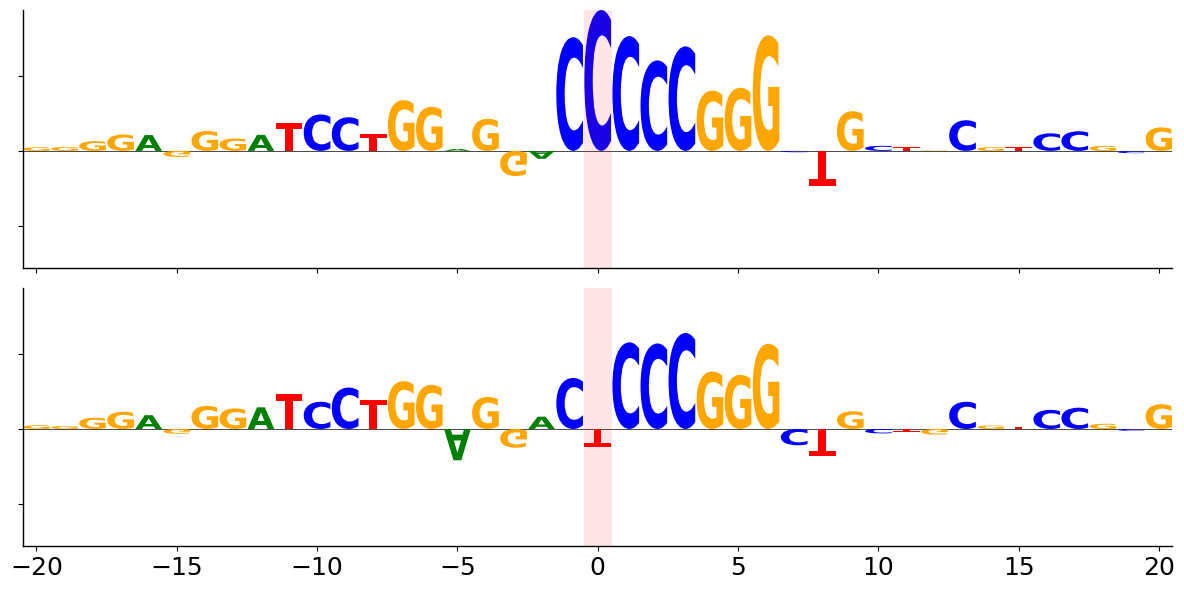

In [4]:
thp1_snp_jobs = [

    ("rs73972710",  641 - 1, int(1710 / 2 + 641 - 1)),

]

thp1_results = {}

for rsid, major_idx, minor_idx in thp1_snp_jobs:
    print(f"Running {rsid}")
    plot_thp1_consensus_main_figure(
        major_index=major_idx,
        minor_index=minor_idx,
        output_file=f'{rsid}_thp1LPSIFNGvsNaive_consensus_main.pdf',
        start=-20,
        end=20,
        thp1_models=['THP1_LPSIFNGvsNaive-model-best_SHAP'],
        model_weights=None,
        normalization='sum_abs',
        tick_fontsize=18,
        figure_size=(12, 6),
        snp_position=0,
        verbose=True
    )